In [1]:
path_to_dodem = '/Users/jmdunca2/do-dem/'
from sys import path as sys_path
sys_path.append(path_to_dodem+'/dodem/')

import HARP_and_age as haa
import nustar_utilities as nuutil
import lightcurves as lc
import visualize_dem_results as viz
import all_nu_analysis as ana

import pickle
import importlib

import numpy as np
from matplotlib import pyplot as plt
from astropy import units as u
import matplotlib.dates as mdates

from astropy.visualization import quantity_support
quantity_support()

with open('/Users/jmdunca2/do-dem/reference_files/all_targets_postghost_postshut.pickle', 'rb') as f:
    all_targets = pickle.load(f)

In [2]:
#Make EM > 10 MK needed arrays etc

with open('/Users/jmdunca2/do-dem/reference_files/samesames.pickle', 'rb') as f:
    data = pickle.load(f)

samesames = data['same region lists']
grf = data['ghost ray flags']
filelist = ana.get_same_region_file_lists(samesames, all_targets)


#Factor to adjust integrated EM values
area_i = 100**2
area_m = np.pi*150**2
#print(area_i, area_m)
factor = area_m/area_i
#factor=1


allgood=0
region_above10s=[]
region_totaltime=[]
region_totalvals=[]
times_per=[]
contigs=[]
all_times=[]
all_intervals=[]

region_int_above10s=[]

for i in range(0, len(filelist)):
    gf = filelist[i]

    vals = []
    above10s_ = []
    totaltime = 0
    times=[]
    durs=[]
    for f_ in gf:
        with open(f_, 'rb') as f:
            data = pickle.load(f)
        time = data['time_interval']
        dur = (time[1]-time[0]).to(u.s).value
        durs.append(dur)
        times.append(time)
        above10s = data['above_10MK']
        #print(f_)
        #print(above10s)
        above10s_.append(above10s[0])
        vals.append([dur*above10s[0]])
        totaltime+=dur

    contiguous, intervals, int_inds = ana.check_contig(times)
    print(samesames[i])
    print(contiguous)
    print(int_inds)
    print(intervals)
    #print(times)
    print('')
    if vals:
        region_int_above10s_=[]
        for ii in int_inds:
            indx = np.arange(ii[0],ii[1])
            int_vals = np.array(vals)[indx]
            int_a10s = np.array(above10s_)[indx]
            int_durs = np.array(durs)[indx]
            region_int_above10s_.append([np.sum(int_vals)/np.sum(int_durs)*factor, np.min(int_a10s)*factor, np.max(int_a10s)*factor])

        region_int_above10s.append(region_int_above10s_)
        
        region_above10s.append([np.sum(vals)/totaltime*factor, np.min(above10s_)*factor, np.max(above10s_)*factor])
        region_totaltime.append(totaltime)
        region_totalvals.append(len(vals))
        times_per.append([np.min(times), np.max(times)])
        all_times.append(times)
        all_intervals.append(intervals)
        contigs.append(contiguous)

    else:
        region_int_above10s.append([])
        region_above10s.append([0, 0, 0])
        region_totaltime.append(0)
        region_totalvals.append(0)
        times_per.append([])
        all_times.append([])
        all_intervals.append([])
        contigs.append(False)
    



outputs = [region_above10s, region_totaltime, region_totalvals, times_per, all_times, all_intervals, contigs]


['01-nov-14_1 region_0']
True
[(0, 2)]
[[<Time object: scale='utc' format='datetime' value=[datetime.datetime(2014, 11, 1, 21, 34, 45)
 datetime.datetime(2014, 11, 1, 21, 41, 55)]>, <Time object: scale='utc' format='datetime' value=[datetime.datetime(2014, 11, 1, 21, 41, 55)
 datetime.datetime(2014, 11, 1, 21, 47, 50)]>]]

['01-nov-14_1 region_1']
True
[(0, 1)]
[[<Time object: scale='utc' format='datetime' value=[datetime.datetime(2014, 11, 1, 21, 34, 45)
 datetime.datetime(2014, 11, 1, 21, 47, 50)]>]]

['11-dec-14 region_0']
True
[(0, 1)]
[[<Time object: scale='utc' format='datetime' value=[datetime.datetime(2014, 12, 11, 18, 38, 55)
 datetime.datetime(2014, 12, 11, 18, 47, 5)]>]]

['19-feb-16 region_0']
False
[(0, 1), (1, 5), (5, 6)]
[[<Time object: scale='utc' format='datetime' value=[datetime.datetime(2016, 2, 19, 18, 54, 50)
 datetime.datetime(2016, 2, 19, 19, 8, 55)]>], [<Time object: scale='utc' format='datetime' value=[datetime.datetime(2016, 2, 19, 20, 31, 30)
 datetime.dateti

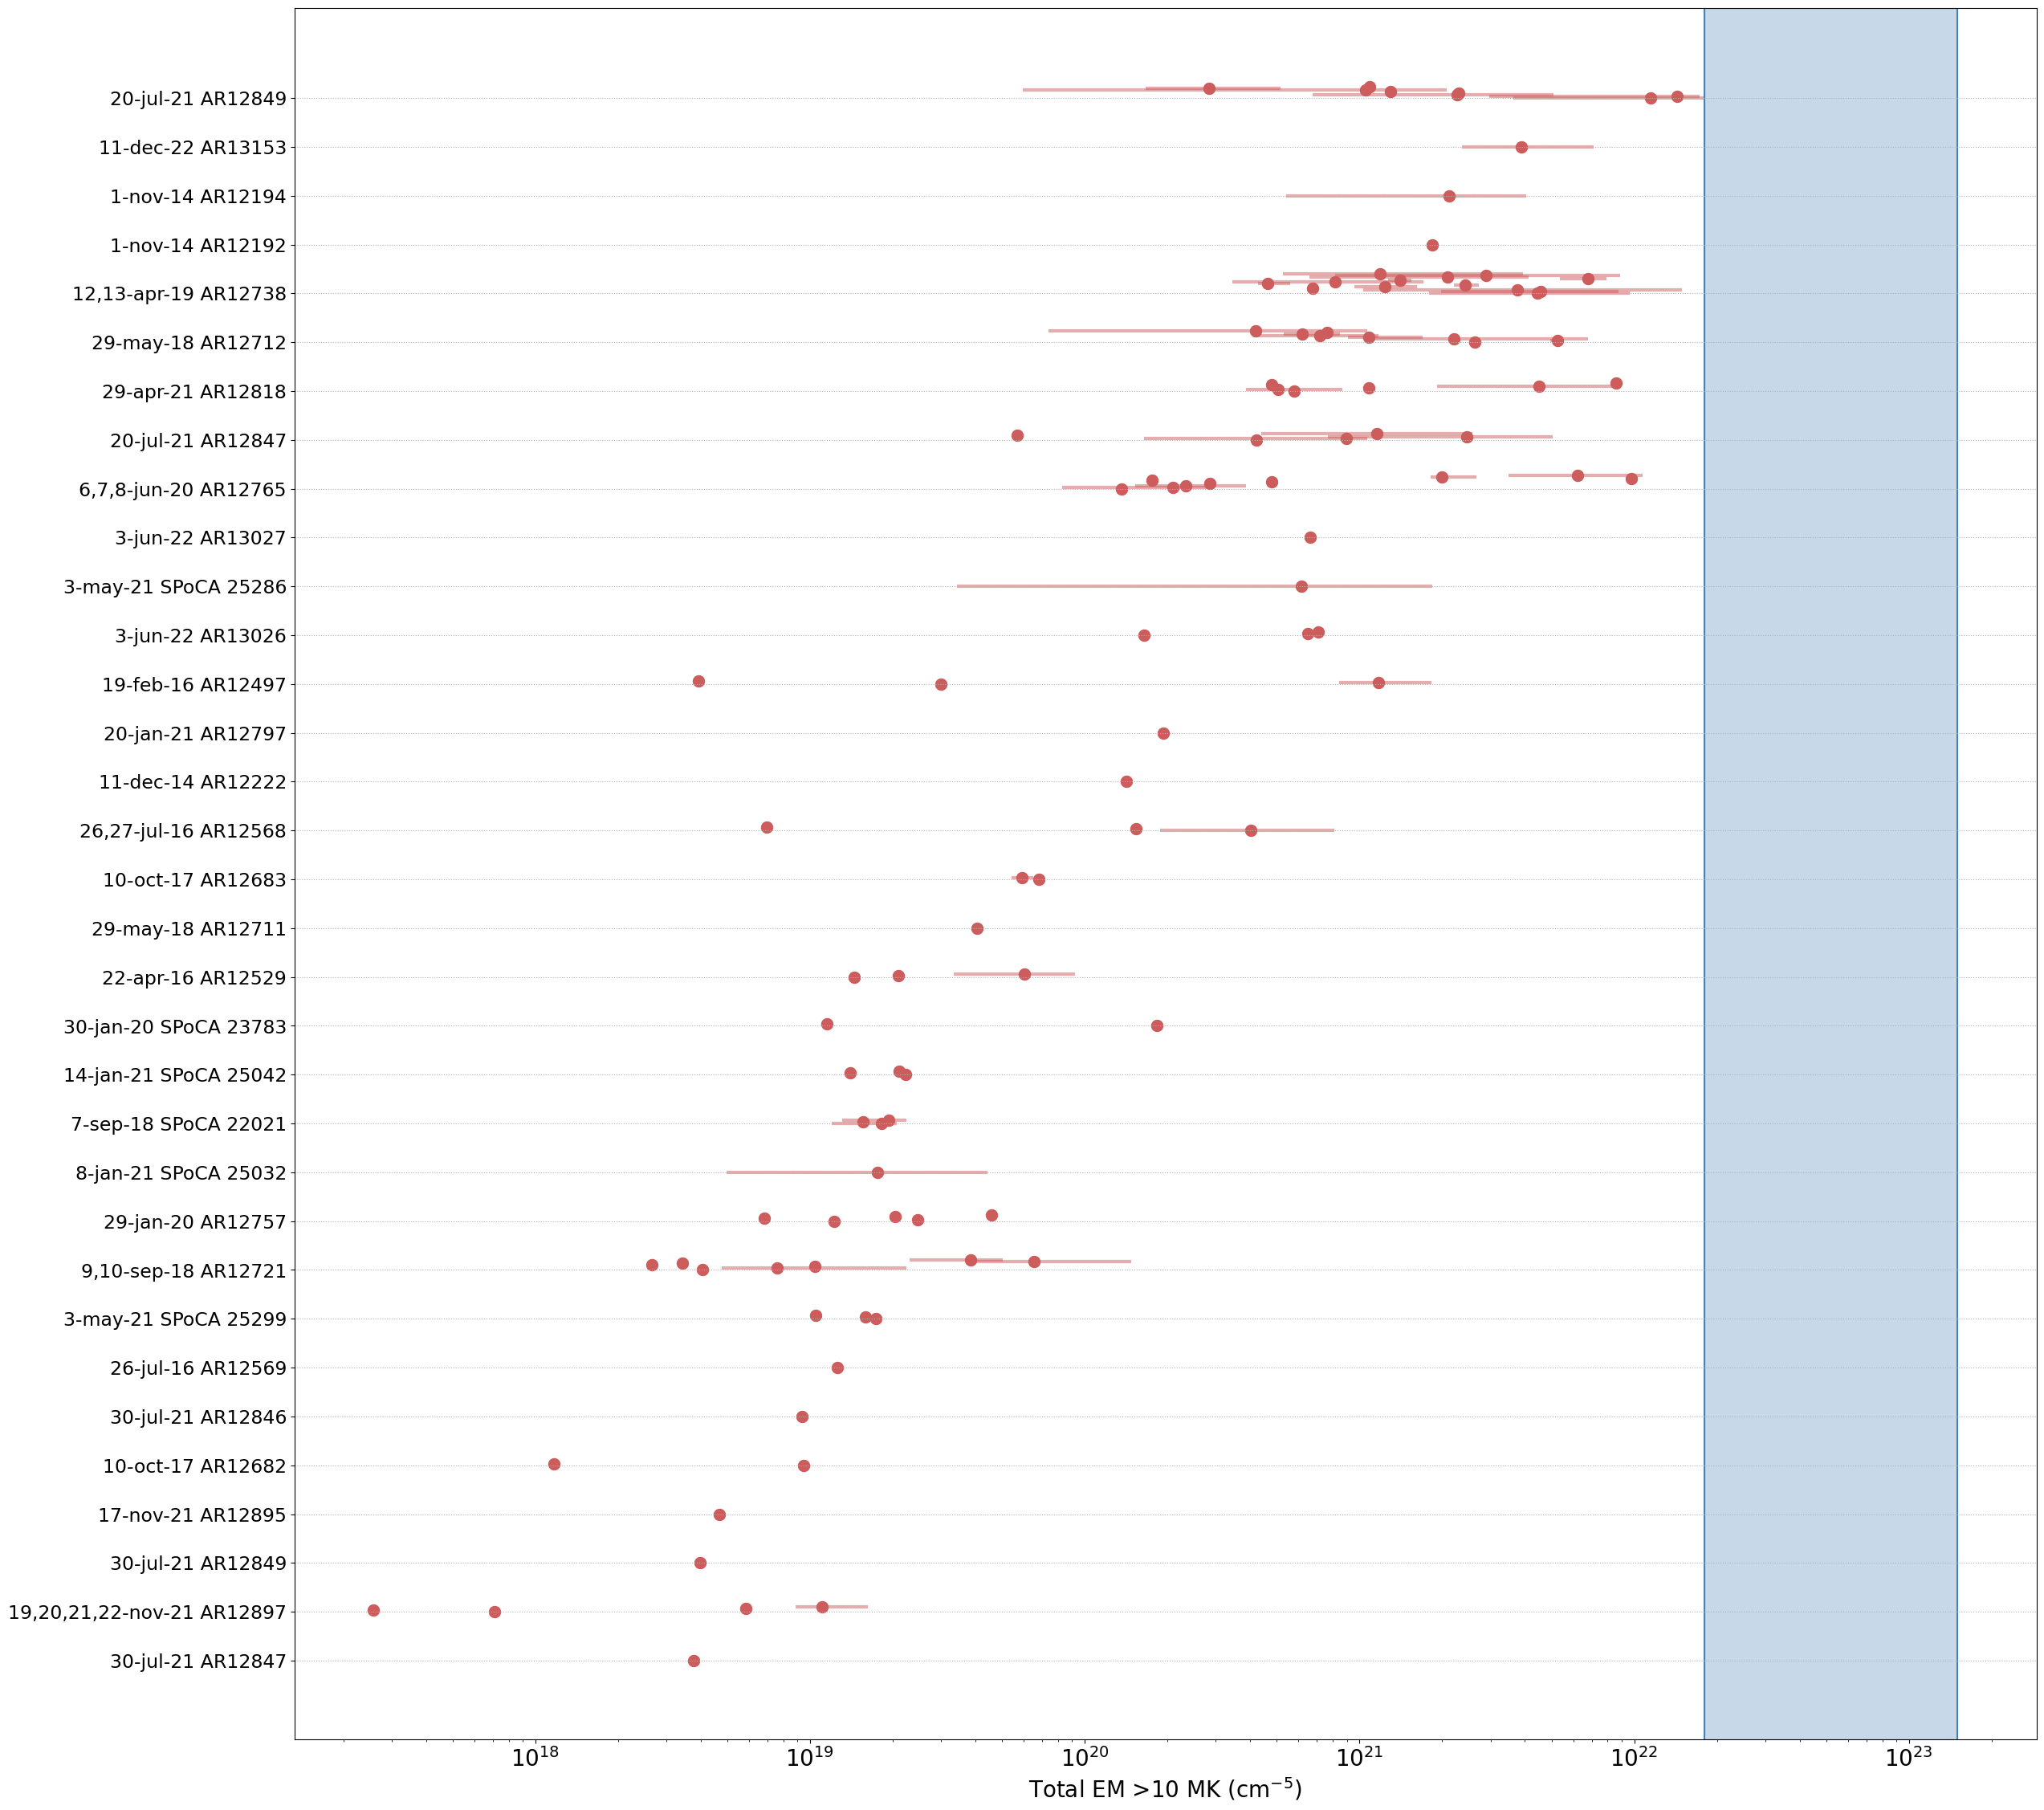

In [3]:
order = np.argsort(np.array(region_above10s)[:,0])
regids = [samesames[i] for i in order]

plotlabs = ana.make_labels(regids, all_targets)
region_int_above10s_sort = [region_int_above10s[i] for i in order]


fig, ax = plt.subplots(1, 1, figsize=(28,28))

val=0
for rr in region_int_above10s_sort:
    regionabove10s=rr
    xerrl = (np.array(regionabove10s)[:,0]- np.array(regionabove10s)[:,1])
    xerrl[np.where(xerrl < 1e10)] = 0.0
    xerrh = (np.array(regionabove10s)[:,2] - np.array(regionabove10s)[:,0])
    xerrh[np.where(xerrh < 1e10)] = 0.0
    
    xerr = [xerrl, xerrh]

    vert=np.arange(0, (len(rr)))*0.1+val
    if len(vert) ==0:
        vert=np.array([val])
    ax.errorbar(np.array(regionabove10s)[:,0], vert, 
                xerr=xerr,
               linestyle='', marker='o', linewidth=3, alpha=0.5, markersize=10, color='indianred',zorder=0)
    ax.errorbar(np.array(regionabove10s)[:,0], vert, 
               linestyle='', marker='o', linewidth=3, markersize=10, color='indianred', zorder=1)#, label='New Regions', zorder=1)
    val+=3

ax.set_yticks(np.arange(0, val, 3)) #[2:]
ax.set_yticklabels(labels=plotlabs, fontsize=17)
ax.set_xscale('log')
ax.grid(axis = 'y', linestyle='dotted')
plt.xticks(fontsize=20)
ax.set_xlabel('Total EM >10 MK ('+(u.cm**(-5)).to_string('latex_inline')+')', fontsize=20)
ax.axvline(1.8e22, color='steelblue', zorder=0)
ax.axvline(1.5e23, color='steelblue', zorder=0)
ax.axvspan(1.8e22, 1.5e23, alpha=0.3, color='steelblue', label='Ishikawa+2017 95% Interval', zorder=0)

plt.savefig('before_cstat_check_all_contiguous_postcstat_newuncert.png', dpi=300)

Make a version of the above 10 MK plot with uncertainties rather than ranges, and which does not weight by duration.

['01-nov-14_1 region_0']
True
[(0, 2)]
[[<Time object: scale='utc' format='datetime' value=[datetime.datetime(2014, 11, 1, 21, 34, 45)
 datetime.datetime(2014, 11, 1, 21, 41, 55)]>, <Time object: scale='utc' format='datetime' value=[datetime.datetime(2014, 11, 1, 21, 41, 55)
 datetime.datetime(2014, 11, 1, 21, 47, 50)]>]]

['01-nov-14_1 region_1']
True
[(0, 1)]
[[<Time object: scale='utc' format='datetime' value=[datetime.datetime(2014, 11, 1, 21, 34, 45)
 datetime.datetime(2014, 11, 1, 21, 47, 50)]>]]

['11-dec-14 region_0']
True
[(0, 1)]
[[<Time object: scale='utc' format='datetime' value=[datetime.datetime(2014, 12, 11, 18, 38, 55)
 datetime.datetime(2014, 12, 11, 18, 47, 5)]>]]

['19-feb-16 region_0']
False
[(0, 1), (1, 5), (5, 6)]
[[<Time object: scale='utc' format='datetime' value=[datetime.datetime(2016, 2, 19, 18, 54, 50)
 datetime.datetime(2016, 2, 19, 19, 8, 55)]>], [<Time object: scale='utc' format='datetime' value=[datetime.datetime(2016, 2, 19, 20, 31, 30)
 datetime.dateti

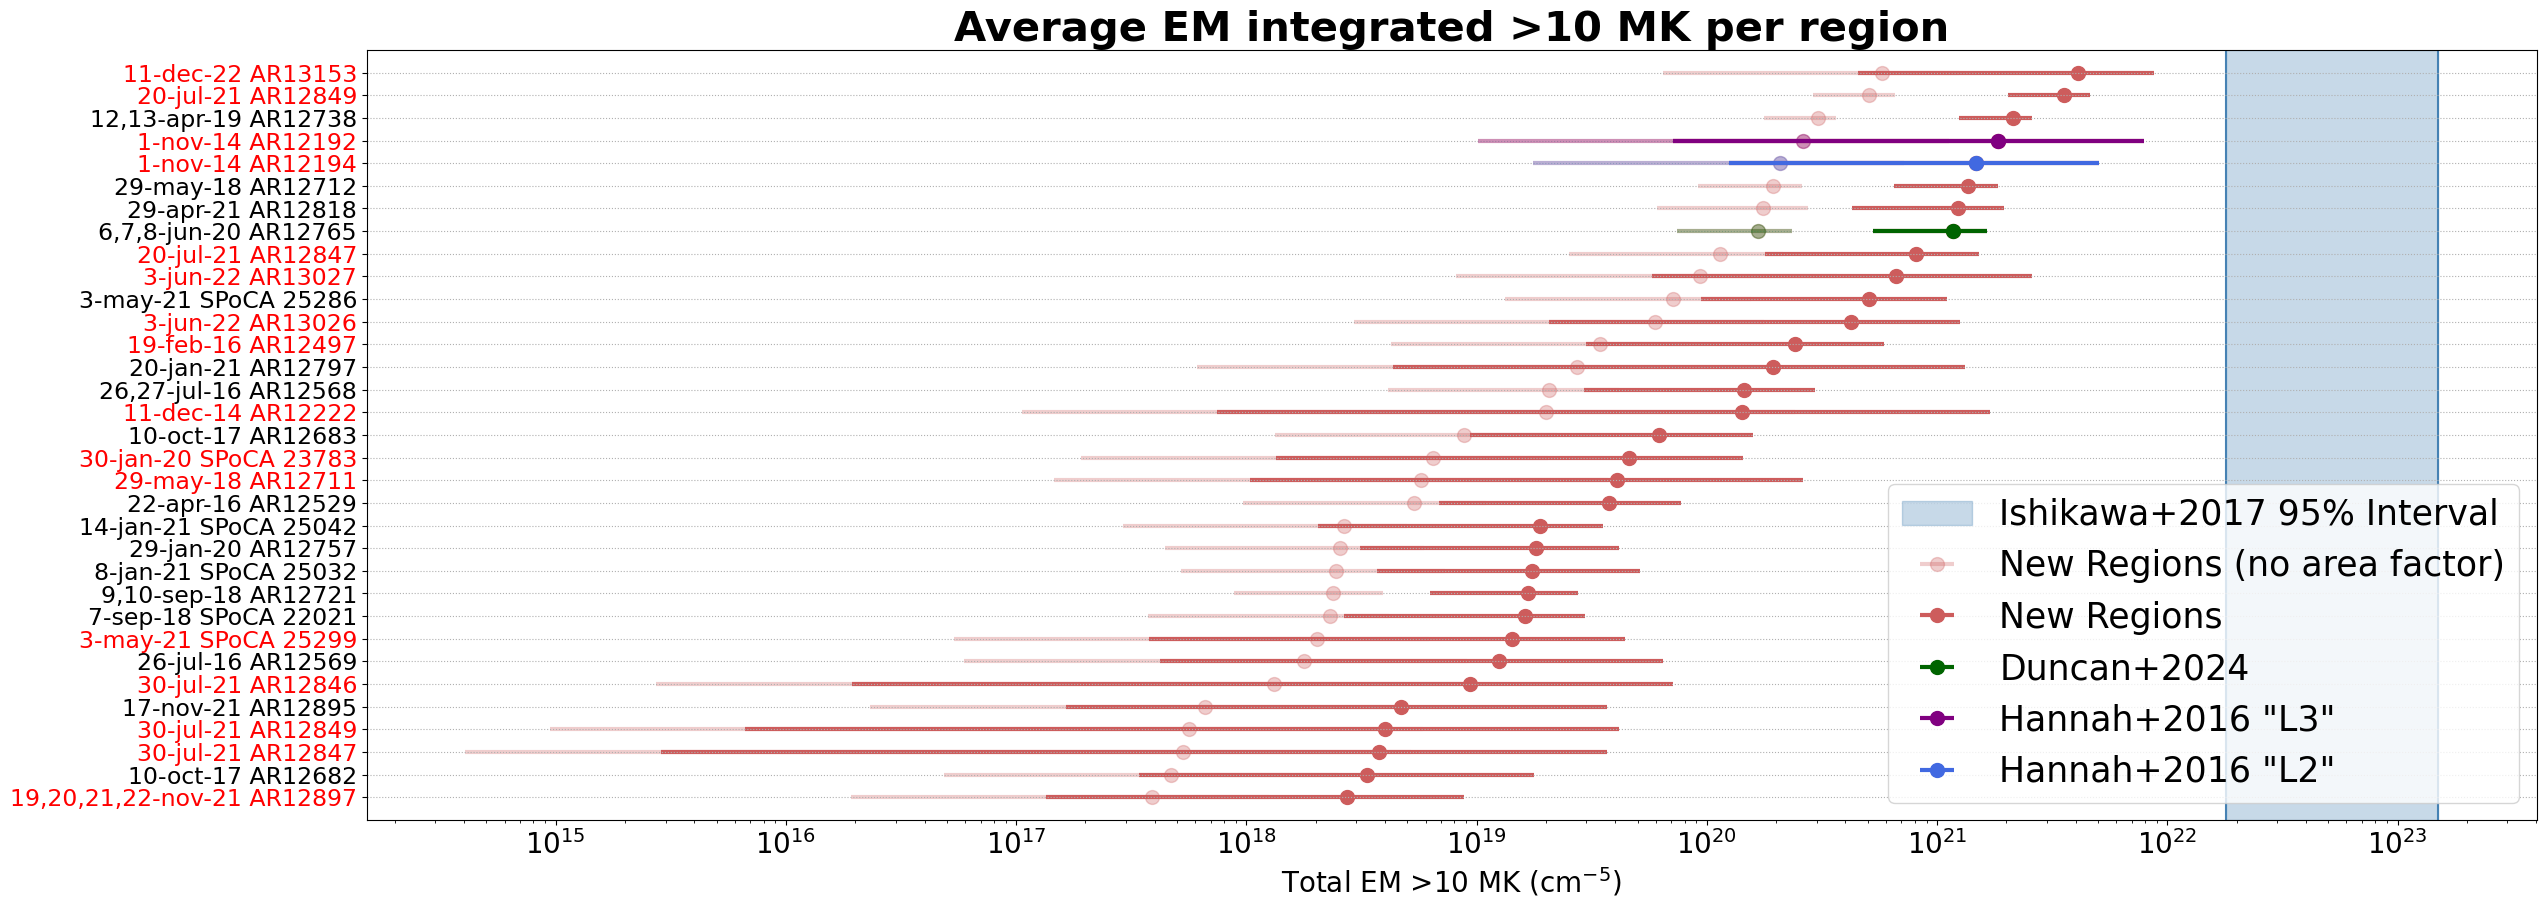

In [3]:
#Make EM > 10 MK needed arrays etc

duration_weight=False

with open('/Users/jmdunca2/do-dem/reference_files/samesames.pickle', 'rb') as f:
    data = pickle.load(f)

samesames = data['same region lists']
grf = data['ghost ray flags']
filelist = ana.get_same_region_file_lists(samesames, all_targets)


#Factor to adjust integrated EM values
area_i = 100**2
area_m = np.pi*150**2
#print(area_i, area_m)
factor = area_m/area_i
#factor=1


allgood=0
region_above10s=[]
region_totaltime=[]
region_totalvals=[]
times_per=[]
contigs=[]
all_times=[]
all_intervals=[]

region_int_above10s=[]

for i in range(0, len(filelist)):
    gf = filelist[i]

    vals = []
    above10s_ = []
    totaltime = 0
    times=[]
    durs=[]
    ups=[]
    downs=[]
    for f_ in gf:
        with open(f_, 'rb') as f:
            data = pickle.load(f)
        #print(f_)
        #print(data.keys())
        time = data['time_interval']
        dur = (time[1]-time[0]).to(u.s).value
        durs.append(dur)
        times.append(time)
        above10s = data['above_10MK']
        #print(f_)
        #print(above10s)
        above10s_.append(above10s[0])
        vals.append([dur*above10s[0]])
        totaltime+=dur
        ups.append(above10s[2])
        downs.append(above10s[1])

    contiguous, intervals, int_inds = ana.check_contig(times)
    print(samesames[i])
    print(contiguous)
    print(int_inds)
    print(intervals)
    #print(times)
    print('')
    if vals:
        region_int_above10s_=[]
        for ii in int_inds:
            indx = np.arange(ii[0],ii[1])
            int_vals = np.array(vals)[indx]
            int_a10s = np.array(above10s_)[indx]
            int_durs = np.array(durs)[indx]
            region_int_above10s_.append([np.sum(int_vals)/np.sum(int_durs)*factor, np.min(int_a10s)*factor, np.max(int_a10s)*factor])

        region_int_above10s.append(region_int_above10s_)

        ldowns = np.log10(np.array(downs))
        lups = np.log10(np.array(ups))
        la10s = np.log10(np.array(above10s_))
        
        if duration_weight:
            weighted_val = np.sum([la10s[i]*durs[i]/totaltime for i in range(0, len(la10s))])
            ddif = weighted_val-ldowns
            ein = np.sum([(ddif[i]*durs[i]/totaltime)**2 for i in range(0, len(la10s))])**(1/2)
            edwn = 10**(weighted_val - ein)
            udiff = lups-weighted_val
            euin = np.sum([(udiff[i]*durs[i]/totaltime)**2 for i in range(0, len(la10s))])**(1/2)
            eup = 10**(euin + weighted_val)
            print(ein, euin)
            print(weighted_val, edwn, eup)
            input_val = 10**(weighted_val)
        else:
            lmean = np.mean(la10s)
            ddif = la10s-ldowns
            edwn = 10**(lmean-np.sum([dd**2 for dd in ddif])**(1/2)/len(ddif))
            udif = lups-la10s
            eup = 10**(np.sum([dd**2 for dd in udif])**(1/2)/len(udif) + lmean)
            input_val = 10**(lmean)
        

        
        #region_above10s.append([np.sum(vals)/totaltime*factor, np.min(downs)*factor, np.max(ups)*factor])
        region_above10s.append([input_val*factor, edwn*factor, eup*factor]) 
        region_totaltime.append(totaltime)
        region_totalvals.append(len(vals))
        times_per.append([np.min(times), np.max(times)])
        all_times.append(times)
        all_intervals.append(intervals)
        contigs.append(contiguous)

    else:
        region_int_above10s.append([])
        region_above10s.append([0, 0, 0])
        region_totaltime.append(0)
        region_totalvals.append(0)
        times_per.append([])
        all_times.append([])
        all_intervals.append([])
        contigs.append(False)
    



outputs = [region_above10s, region_totaltime, region_totalvals, times_per, all_times, all_intervals, contigs]


order = np.argsort(np.array(region_above10s)[:,0])
regids = [samesames[i] for i in order]
grf = [grf[i] for i in order]

ghost_ticks = np.where(grf)[0]

plotlabs = ana.make_labels(regids, all_targets)

#print('')
#print(len(labs))
#print(len(order))

region_time_hr = np.array((region_totaltime*u.s).to(u.hr))
#print(region_time_hr[order])


fig, ax = plt.subplots(1, 1, figsize=(28,10))


xerrl = (np.array(region_above10s)[:,0][order]/factor - np.array(region_above10s)[:,1][order]/factor)
xerrl[np.where(xerrl < 1e10)] = 0.0
xerrh = (np.array(region_above10s)[:,2][order]/factor - np.array(region_above10s)[:,0][order]/factor)
xerrh[np.where(xerrh < 1e10)] = 0.0

#xerr = [(np.array(region_above10s)[:,0][order] - np.array(region_above10s)[:,1][order]), 
#        (np.array(region_above10s)[:,2][order] - np.array(region_above10s)[:,0][order])]

xerr_nf = [xerrl, xerrh]

ax.errorbar(np.array(region_above10s)[:,0][order]/factor, np.arange(0, len(filelist), 1), 
            xerr=xerr_nf,
           linestyle='', marker='o', linewidth=3, markersize=10, color='indianred', 
            label='New Regions (no area factor)', alpha=0.3, zorder=0)

xerrl = (np.array(region_above10s)[:,0][order] - np.array(region_above10s)[:,1][order])
xerrl[np.where(xerrl < 1e10)] = 0.0
xerrh = (np.array(region_above10s)[:,2][order] - np.array(region_above10s)[:,0][order])
xerrh[np.where(xerrh < 1e10)] = 0.0

#xerr = [(np.array(region_above10s)[:,0][order] - np.array(region_above10s)[:,1][order]), 
#        (np.array(region_above10s)[:,2][order] - np.array(region_above10s)[:,0][order])]

xerr = [xerrl, xerrh]

ax.errorbar(np.array(region_above10s)[:,0][order], np.arange(0, len(filelist), 1), 
            xerr=xerr,
           linestyle='', marker='o', linewidth=3, markersize=10, color='indianred', label='New Regions', zorder=1)



oneerr = np.zeros((2,1))

ginds = [25, 29, 28]
colors = ['darkgreen', 'purple', 'royalblue']
labels = ['Duncan+2024', 'Hannah+2016 "L3"', 'Hannah+2016 "L2"']
gc=0
for gind in ginds:
    oneerr[0] = xerr[0][gind]
    oneerr[1] = xerr[1][gind]
    
    print(oneerr)
    
    ax.errorbar(np.array(region_above10s)[:,0][order][gind]/factor, np.arange(0, len(filelist), 1)[gind],
                xerr=oneerr/factor,
                linestyle='', marker='o', color=colors[gc], linewidth=3, markersize=10, alpha=0.3, zorder=2) #, s=140)
    
    
    ax.errorbar(np.array(region_above10s)[:,0][order][gind], np.arange(0, len(filelist), 1)[gind],
                xerr=oneerr,
                linestyle='', marker='o', color=colors[gc], linewidth=3, markersize=10, label=labels[gc], zorder=2) #, s=140)

    gc+=1



fntsz=25
ax.set_xscale('log')
ax.axvline(1.8e22, color='steelblue', zorder=0)
ax.axvline(1.5e23, color='steelblue', zorder=0)
ax.axvspan(1.8e22, 1.5e23, alpha=0.3, color='steelblue', label='Ishikawa+2017 95% Interval', zorder=0)
ax.set_yticks(np.arange(0, len(filelist))) #[2:]
ax.set_yticklabels(labels=plotlabs, fontsize=17) #[2:]
plt.xticks(fontsize=20)
ax.set_xlabel('Total EM >10 MK ('+(u.cm**(-5)).to_string('latex_inline')+')', fontsize=20)
ax.grid(axis = 'y', linestyle='dotted')
ax.legend(loc='lower right', fontsize=fntsz)
ax.set_ylim([-1,len(filelist)])
#ax.set_xlim([4e17,2e24])
ax.set_title('Average EM integrated >10 MK per region', fontsize=30, fontweight='bold')
for i in ghost_ticks:
    ax.get_yticklabels()[i].set_color('red')
print('')

plt.savefig('per_region_above10_uncertainty_bounds_asym_full_prop_noweight.png', dpi=300)




Rather than plotting the full range of the values for a given region, or the full range of the values for a given contiguous interval, what about plotting all of the values with their uncertainties?

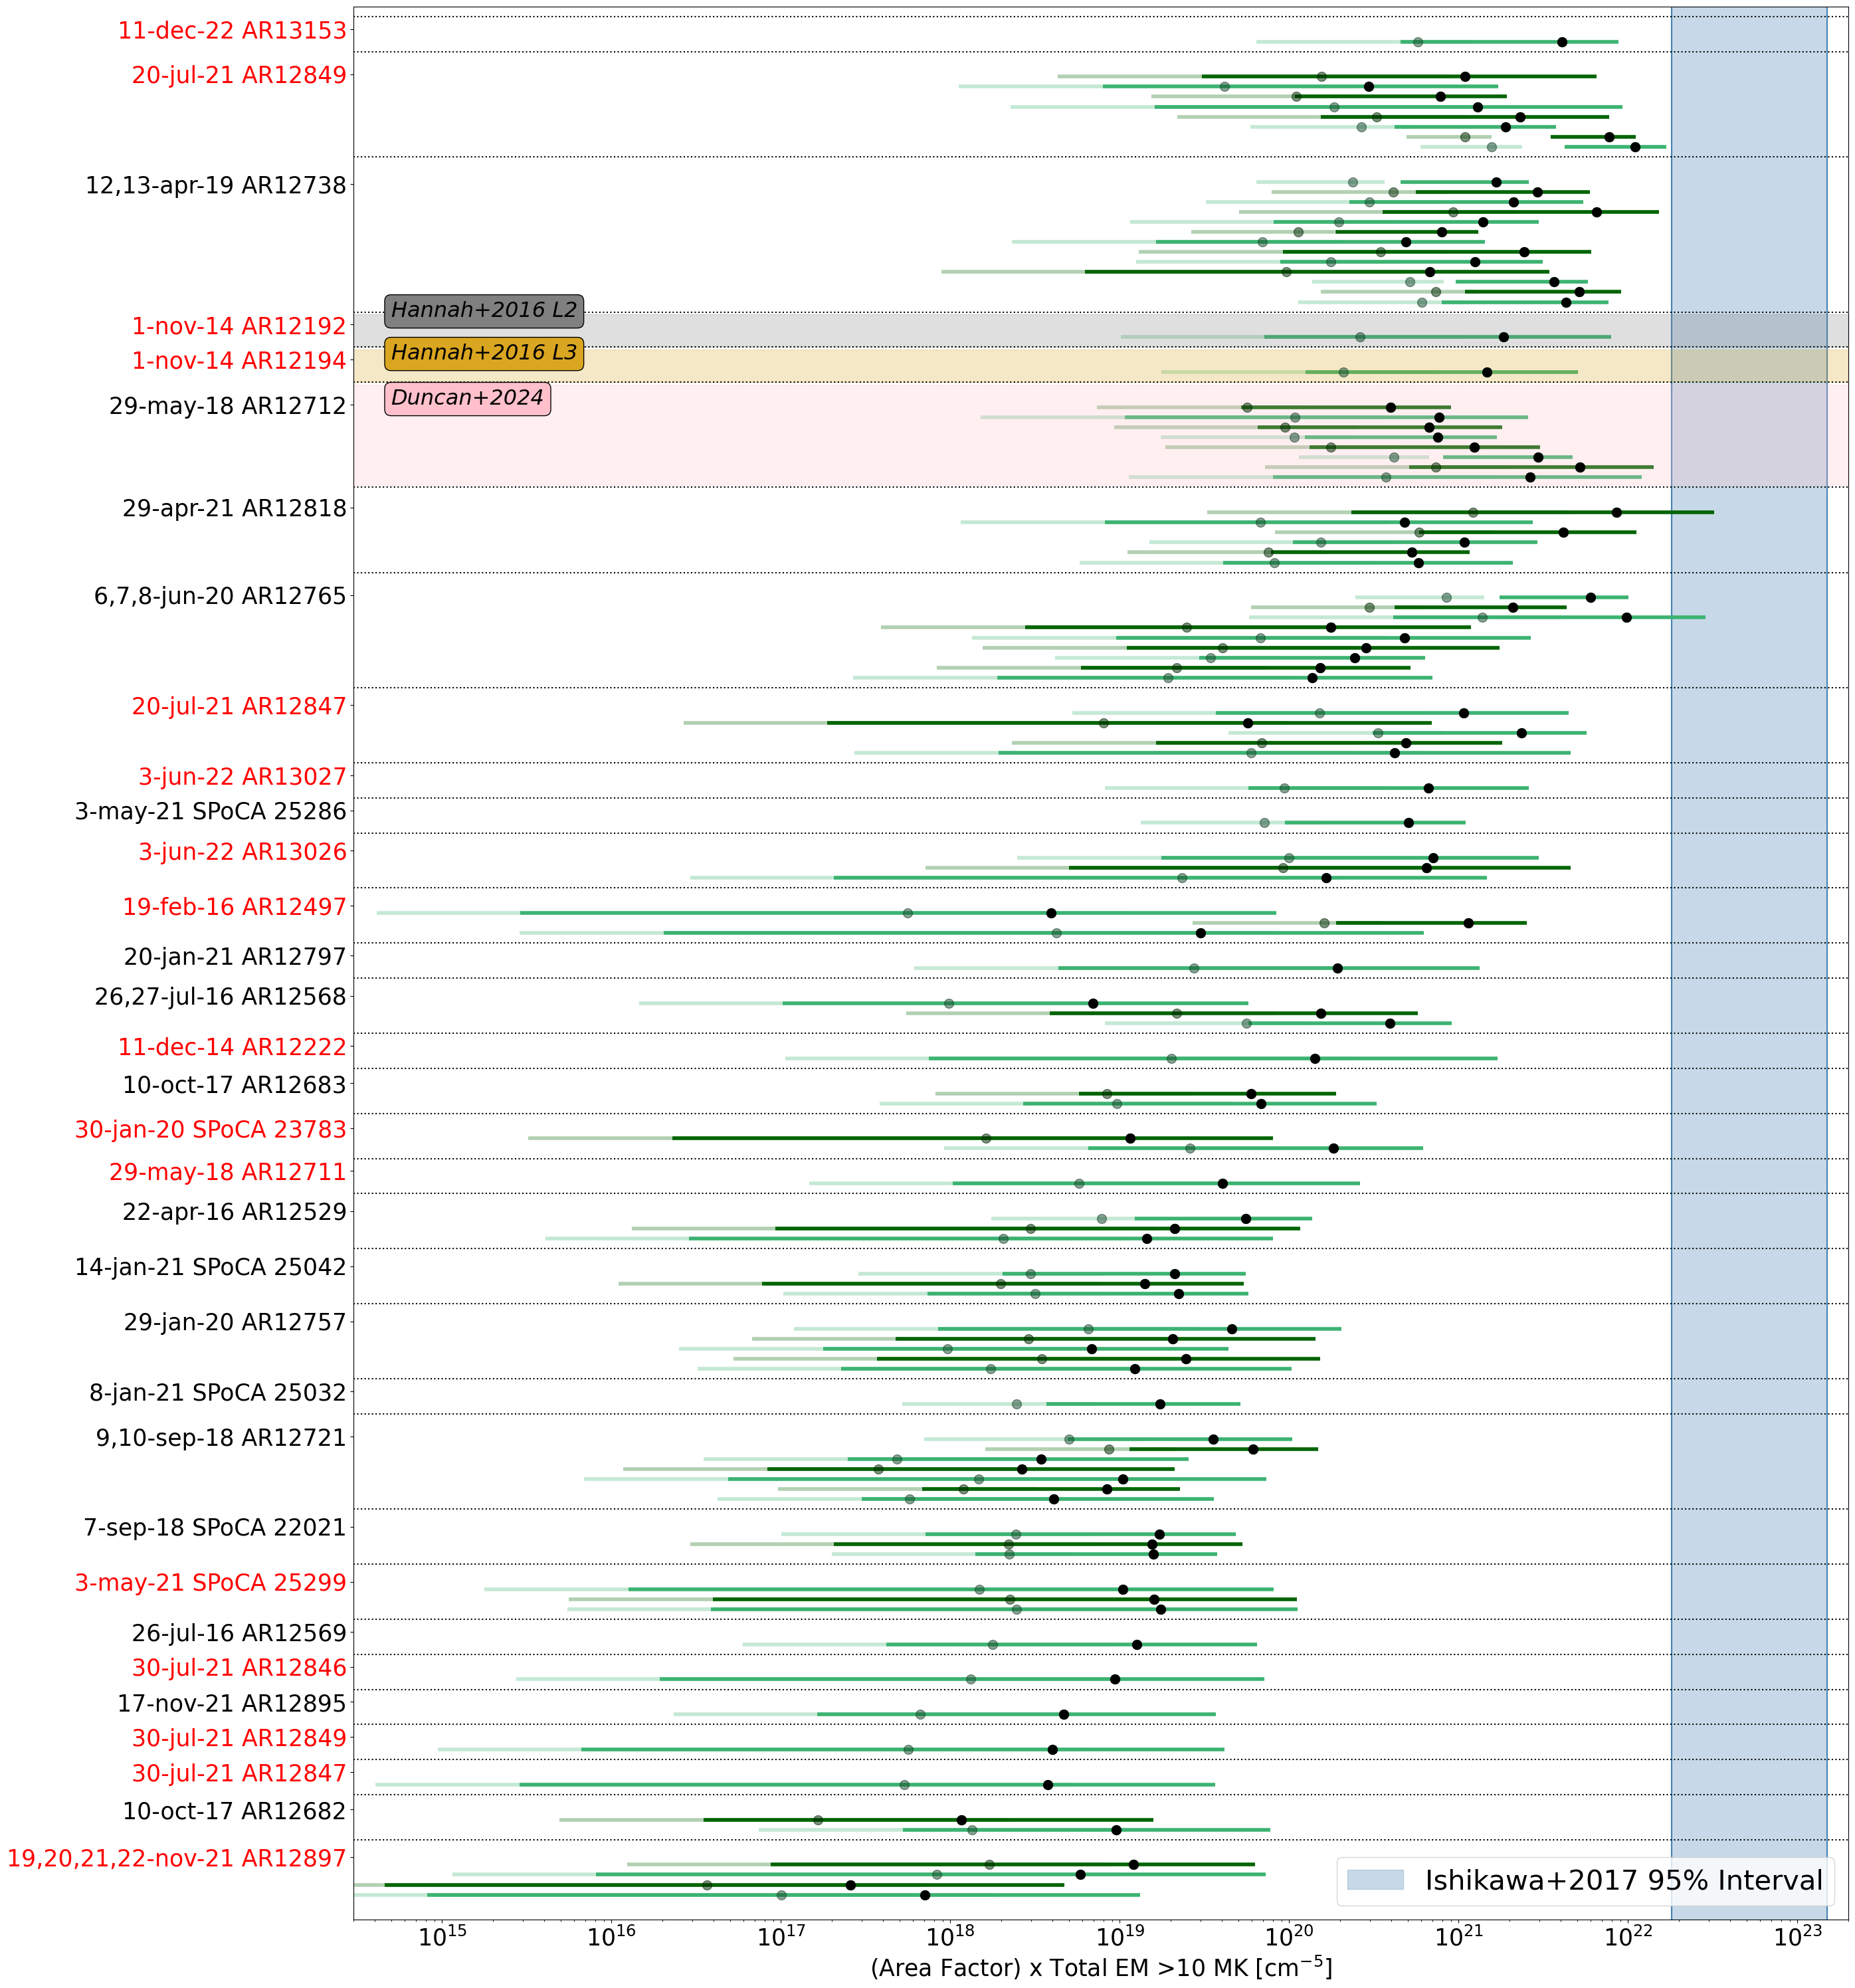

In [4]:
#Make EM > 10 MK needed arrays etc

plot_all_intervals=False
plot_peak_ratio=False
plot_all_contig=True

labelfontsize=25

with open('/Users/jmdunca2/do-dem/reference_files/samesames.pickle', 'rb') as f:
    data = pickle.load(f)


samesames = data['same region lists']
grf = data['ghost ray flags']
#Lists per region
filelist = ana.get_same_region_file_lists(samesames, all_targets)

filelist = [filelist[i] for i in order]
samesames = [samesames[i] for i in order]
grf = [grf[i] for i in order]

#Factor to adjust integrated EM values
area_i = 100**2
area_m = np.pi*150**2
#print(area_i, area_m)
factor = area_m/area_i
#factor=1


# allgood=0
# region_above10s=[]
# region_totaltime=[]
# region_totalvals=[]
# times_per=[]
# contigs=[]
# all_times=[]
# all_intervals=[]

# region_int_above10s=[]

fig, ax = plt.subplots(1, 1, figsize=(28,30), tight_layout={'pad': 1})

ylabelvals = []
val=0
for i in range(0, len(filelist)):
    gf = filelist[i]

    #VERSION WHERE WE PLOT ALL FILES AT RANDOM FOR THE REGION
    #==============================================================
    # regnum=0
    # for f_ in gf:
    #     with open(f_, 'rb') as f:
    #         data = pickle.load(f)

    #     vert=val
    #     xerrl = (np.array([data['above_10MK'][0]- data['above_10MK'][1]]))
    #     #xerrl[np.where(xerrl < 1e10)] = 0.0
    #     xerrh = (np.array([data['above_10MK'][2] - data['above_10MK'][0]]))
    #     #xerrh[np.where(xerrh < 1e10)] = 0.0
        
    #     xerr = [xerrl, xerrh]

    #     ax.errorbar(data['above_10MK'][0], vert, xerr=xerr,
    #             linestyle='', marker='o', linewidth=3, markersize=10, color='indianred', zorder=1)
    #     ax.errorbar(data['above_10MK'][0], vert,
    #             linestyle='', marker='o', linewidth=3, markersize=10, color='black', zorder=2)#, label='New Regions', zorder=1)
    #     val+=1
    #     regnum+=1

    # ylabelvals.append(val-round(regnum/2.)+1.)
    # ax.axhline(val+4, 
    #             linestyle='dotted', color='black')#, label='New Regions', zorder=1)
    # val+=10
    #==============================================================

    regnum=0
    times=[]
    above10s=[]
    peakEMs=[]
    for f_ in gf:
        with open(f_, 'rb') as f:
            data = pickle.load(f)
        times.append(data['time_interval'])
        above10s.append([factor*d for d in data['above_10MK']])
        peakEMs.append(data['max'])

    contiguous, intervals, int_inds = ana.check_contig(times)
    if times:
        flipper=1
        if plot_all_intervals:
            colors=['hi', 'forestgreen', 'teal']
            for ii in int_inds:
                indx = np.arange(ii[0],ii[1])
                int_a10s = np.array(above10s)[indx]
                if plot_peak_ratio:
                    peaks=np.array(peakEMs)[indx]
                    int_a10s = [int_a10s[p]/peaks[p] for p in range(0, len(peaks))]
                for ia10 in int_a10s:
    
                    vert=val
                    xerrl = (np.array([ia10[0]- ia10[1]]))
                    #xerrl[np.where(xerrl < 1e10)] = 0.0
                    xerrh = (np.array([ia10[2] - ia10[0]]))
                    #xerrh[np.where(xerrh < 1e10)] = 0.0
                    
                    xerr = [xerrl, xerrh]                
                    ax.errorbar(ia10[0], vert, xerr=xerr, linestyle='', marker='o', linewidth=3, markersize=10, 
                                color=colors[flipper], zorder=1)
                    ax.errorbar(ia10[0], vert, linestyle='', marker='o', linewidth=3, markersize=10, color='black', zorder=2)
                    val+=1
                    regnum+=1
                flipper*=-1
                    
                val+=5
                
        elif plot_all_contig:
            colors=['hi', 'mediumseagreen', 'darkgreen']
            for ii in int_inds:
                indx = np.arange(ii[0],ii[1])
                int_a10s = np.array(above10s)[indx]
                if plot_peak_ratio:
                    peaks=np.array(peakEMs)[indx]
                    int_a10s = np.array([int_a10s[p]/peaks[p] for p in range(0, len(peaks))])
                    
                #Taking the mean and conducting error propogation
                la10s = np.log10(int_a10s[:,0])
                lmean = np.mean(la10s)
                ddif = la10s - np.log10(int_a10s[:,1])
                #ddif = la10s-ldowns
                edwn = 10**(lmean-np.sum([dd**2 for dd in ddif])**(1/2)/len(ddif))
                udif = np.log10(int_a10s[:,2])-la10s
                eup = 10**(np.sum([dd**2 for dd in udif])**(1/2)/len(udif) + lmean)
                input_val = 10**(lmean)

                vert=val
                xerrl = (np.array([input_val - edwn]))
                #xerrl[np.where(xerrl < 1e10)] = 0.0
                xerrh = (np.array([eup - input_val]))
                #xerrh[np.where(xerrh < 1e10)] = 0.0

                xerr_og = [xerrl/factor, xerrh/factor]
                
                xerr = [xerrl, xerrh]
                ax.errorbar(input_val, vert, xerr=xerr, linestyle='', marker='o', linewidth=4, markersize=10, color=colors[flipper], zorder=1)
                ax.errorbar(input_val/factor, vert, xerr=xerr_og, linestyle='', marker='o', linewidth=4, markersize=10, alpha=0.3, 
                            color=colors[flipper], zorder=1)
                ax.errorbar(input_val, vert, linestyle='', marker='o', linewidth=4, markersize=10, color='black', zorder=2)
                ax.errorbar(input_val/factor, vert, linestyle='', marker='o', linewidth=4, markersize=10, alpha=0.3, 
                            color='black', zorder=2)
                val+=4
                regnum+=1
                flipper*=-1
                    
        
        ylabelvals.append(val-round(regnum/2.)+1.)
        ax.axhline(val+6, linestyle='dotted', color='black')#, label='New Regions', zorder=1)
        val+=10

box_properties = dict(boxstyle='round', facecolor='green', alpha=0.5, edgecolor='black')
for i in range(0, len(plotlabs)):
    #print(plotlabs[i])
    if plotlabs[i] == '1-nov-14 AR12192':
        color='grey'
        box_properties = dict(boxstyle='round', facecolor=color, edgecolor='black')
        ax.text(5e14, ylabelvals[i]+3, 'Hannah+2016 L2', fontsize=labelfontsize-2, style='italic', bbox=box_properties)
        ax.axhspan(ylabelvals[i]-9, ylabelvals[i]+4, color=color, alpha=0.25)
        
    if plotlabs[i] == '1-nov-14 AR12194':
        color='goldenrod'
        box_properties = dict(boxstyle='round', facecolor=color, edgecolor='black')
        ax.text(5e14, ylabelvals[i], 'Hannah+2016 L3', fontsize=labelfontsize-2, style='italic', bbox=box_properties)
        ax.axhspan(ylabelvals[i]-9, ylabelvals[i]+4, color=color, alpha=0.25)
        
    if plotlabs[i] == '29-may-18 AR12712':
        color='pink'
        box_properties = dict(boxstyle='round', facecolor=color, edgecolor='black')
        ax.text(5e14, ylabelvals[i], 'Duncan+2024', fontsize=labelfontsize-2, style='italic', bbox=box_properties)
        ax.axhspan(ylabelvals[i]-32, ylabelvals[i]+8, color=color, alpha=0.25)
        


ax.set_yticks(ylabelvals)#[2:]
ax.set_yticklabels(labels=plotlabs, fontsize=labelfontsize)
ax.set_xscale('log')
plt.xticks(fontsize=labelfontsize)
if not plot_peak_ratio:
    ax.set_xlabel('(Area Factor) x Total EM >10 MK ['+(u.cm**(-5)).to_string('latex_inline')+']', fontsize=labelfontsize)
    ax.axvline(1.8e22, color='steelblue', zorder=0)
    ax.axvline(1.5e23, color='steelblue', zorder=0)
    ax.axvspan(1.8e22, 1.5e23, alpha=0.3, color='steelblue', label='Ishikawa+2017 95% Interval', zorder=0)
ghost_ticks = np.where(grf)[0]
for i in ghost_ticks:
    ax.get_yticklabels()[i].set_color('red')
print('')

ax.set_ylim([-10,val])
ax.set_xlim([3e14,2e23])
ax.legend(loc='lower right', fontsize=labelfontsize+5)

if plot_all_intervals:
    if plot_peak_ratio:
        plt.savefig('all_values_above10_all_peak_rat.png', dpi=300)
    else:
        plt.savefig('all_values_above10_all.png', dpi=300)

if plot_all_contig:
    if plot_peak_ratio:
        plt.savefig('all_values_above10_contig_peak_rat.png', dpi=300)
    else:
        plt.savefig('all_values_above10_contig.png', dpi=300)

7.068583470577035



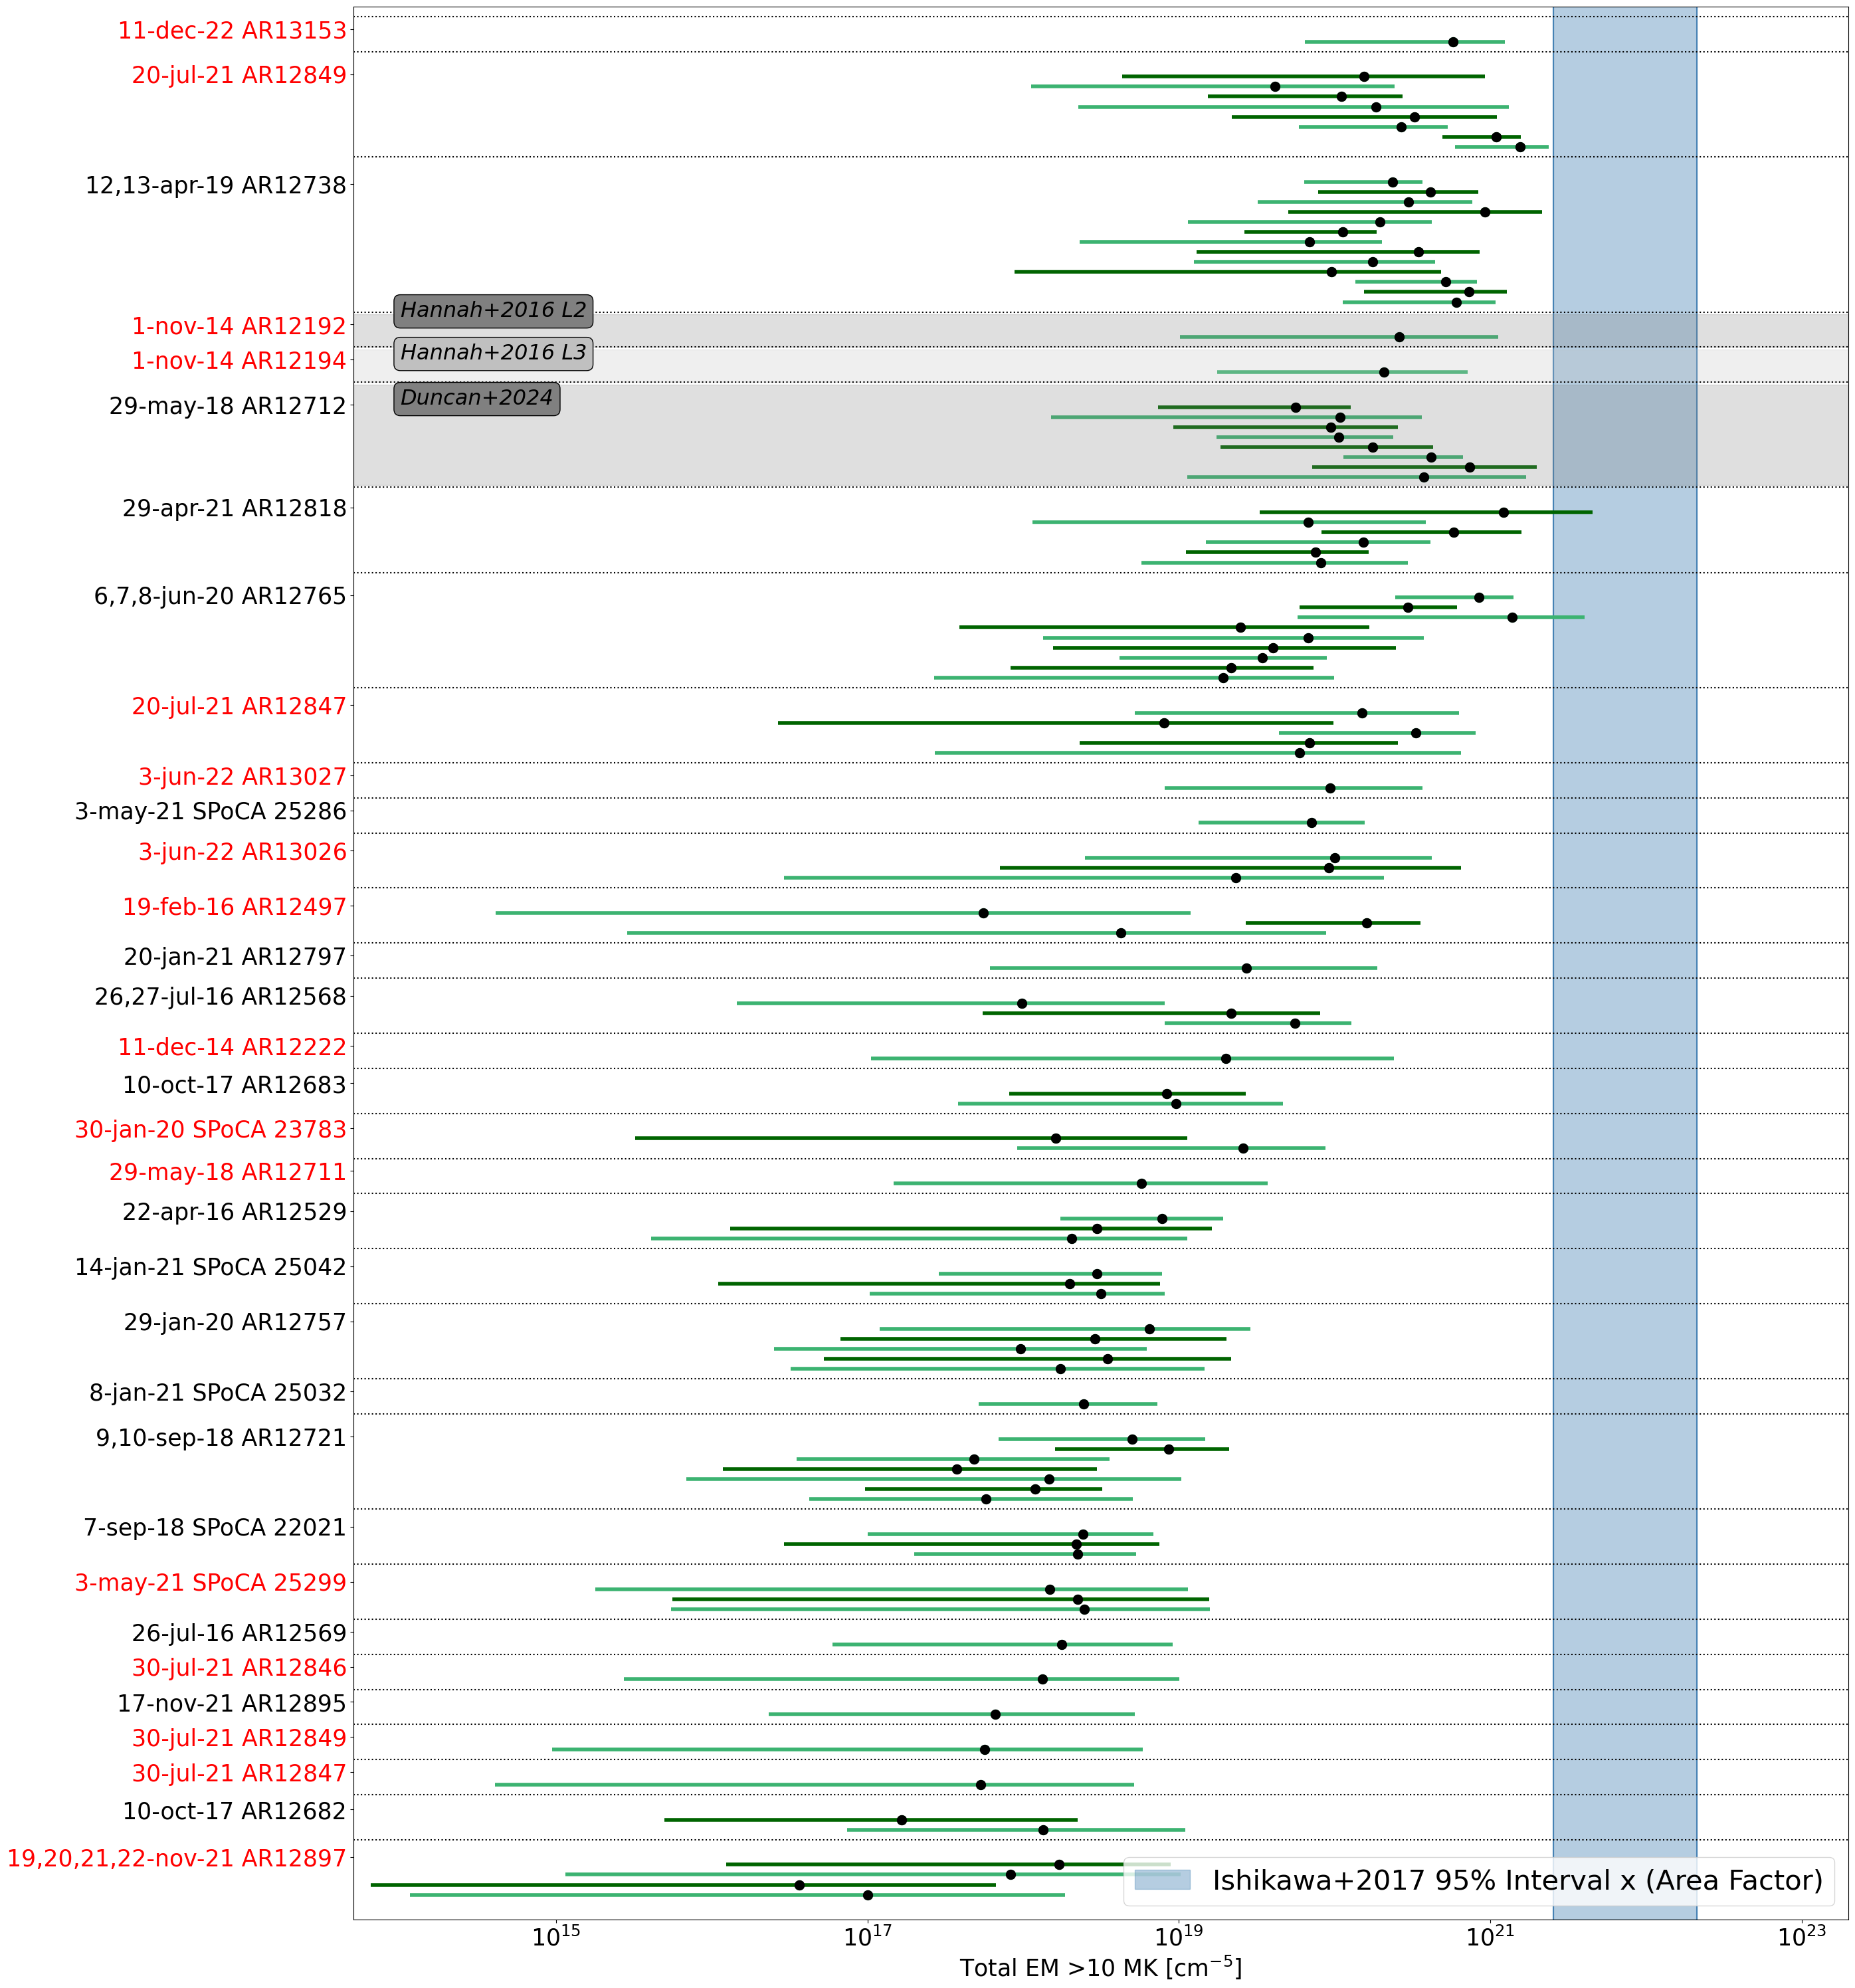

In [5]:
#Make EM > 10 MK needed arrays etc - NEW VERISON WHERE WE SHIFT THE ISHIKAWA RANGE INSTEAD.

plot_all_intervals=False
plot_peak_ratio=False
plot_all_contig=True

labelfontsize=25

with open('/Users/jmdunca2/do-dem/reference_files/samesames.pickle', 'rb') as f:
    data = pickle.load(f)


samesames = data['same region lists']
grf = data['ghost ray flags']
#Lists per region
filelist = ana.get_same_region_file_lists(samesames, all_targets)

filelist = [filelist[i] for i in order]
samesames = [samesames[i] for i in order]
grf = [grf[i] for i in order]

#Factor to adjust integrated EM values
area_i = 100**2
area_m = np.pi*150**2
#print(area_i, area_m)
factor = area_m/area_i
#factor=1
print(factor)


# allgood=0
# region_above10s=[]
# region_totaltime=[]
# region_totalvals=[]
# times_per=[]
# contigs=[]
# all_times=[]
# all_intervals=[]

# region_int_above10s=[]

fig, ax = plt.subplots(1, 1, figsize=(28,30), tight_layout={'pad': 1})

ylabelvals = []
val=0
for i in range(0, len(filelist)):
    gf = filelist[i]

    #VERSION WHERE WE PLOT ALL FILES AT RANDOM FOR THE REGION
    #==============================================================
    # regnum=0
    # for f_ in gf:
    #     with open(f_, 'rb') as f:
    #         data = pickle.load(f)

    #     vert=val
    #     xerrl = (np.array([data['above_10MK'][0]- data['above_10MK'][1]]))
    #     #xerrl[np.where(xerrl < 1e10)] = 0.0
    #     xerrh = (np.array([data['above_10MK'][2] - data['above_10MK'][0]]))
    #     #xerrh[np.where(xerrh < 1e10)] = 0.0
        
    #     xerr = [xerrl, xerrh]

    #     ax.errorbar(data['above_10MK'][0], vert, xerr=xerr,
    #             linestyle='', marker='o', linewidth=3, markersize=10, color='indianred', zorder=1)
    #     ax.errorbar(data['above_10MK'][0], vert,
    #             linestyle='', marker='o', linewidth=3, markersize=10, color='black', zorder=2)#, label='New Regions', zorder=1)
    #     val+=1
    #     regnum+=1

    # ylabelvals.append(val-round(regnum/2.)+1.)
    # ax.axhline(val+4, 
    #             linestyle='dotted', color='black')#, label='New Regions', zorder=1)
    # val+=10
    #==============================================================

    regnum=0
    times=[]
    above10s=[]
    peakEMs=[]
    for f_ in gf:
        with open(f_, 'rb') as f:
            data = pickle.load(f)
        times.append(data['time_interval'])
        #above10s.append([factor*d for d in data['above_10MK']])
        above10s.append([d for d in data['above_10MK']])
        peakEMs.append(data['max'])

    contiguous, intervals, int_inds = ana.check_contig(times)
    if times:
        flipper=1
        if plot_all_intervals:
            colors=['hi', 'forestgreen', 'teal']
            for ii in int_inds:
                indx = np.arange(ii[0],ii[1])
                int_a10s = np.array(above10s)[indx]
                if plot_peak_ratio:
                    peaks=np.array(peakEMs)[indx]
                    int_a10s = [int_a10s[p]/peaks[p] for p in range(0, len(peaks))]
                for ia10 in int_a10s:
    
                    vert=val
                    xerrl = (np.array([ia10[0]- ia10[1]]))
                    #xerrl[np.where(xerrl < 1e10)] = 0.0
                    xerrh = (np.array([ia10[2] - ia10[0]]))
                    #xerrh[np.where(xerrh < 1e10)] = 0.0
                    
                    xerr = [xerrl, xerrh]                
                    ax.errorbar(ia10[0], vert, xerr=xerr, linestyle='', marker='o', linewidth=3, markersize=10, 
                                color=colors[flipper], zorder=1)
                    ax.errorbar(ia10[0], vert, linestyle='', marker='o', linewidth=3, markersize=10, color='black', zorder=2)
                    val+=1
                    regnum+=1
                flipper*=-1
                    
                val+=5
                
        elif plot_all_contig:
            colors=['hi', 'mediumseagreen', 'darkgreen']
            for ii in int_inds:
                indx = np.arange(ii[0],ii[1])
                int_a10s = np.array(above10s)[indx]
                if plot_peak_ratio:
                    peaks=np.array(peakEMs)[indx]
                    int_a10s = np.array([int_a10s[p]/peaks[p] for p in range(0, len(peaks))])
                    
                #Taking the mean and conducting error propogation
                la10s = np.log10(int_a10s[:,0])
                lmean = np.mean(la10s)
                ddif = la10s - np.log10(int_a10s[:,1])
                #ddif = la10s-ldowns
                edwn = 10**(lmean-np.sum([dd**2 for dd in ddif])**(1/2)/len(ddif))
                udif = np.log10(int_a10s[:,2])-la10s
                eup = 10**(np.sum([dd**2 for dd in udif])**(1/2)/len(udif) + lmean)
                input_val = 10**(lmean)

                vert=val
                xerrl = (np.array([input_val - edwn]))
                #xerrl[np.where(xerrl < 1e10)] = 0.0
                xerrh = (np.array([eup - input_val]))
                #xerrh[np.where(xerrh < 1e10)] = 0.0

                #xerr_og = [xerrl/factor, xerrh/factor]
                
                xerr = [xerrl, xerrh]
                ax.errorbar(input_val, vert, xerr=xerr, linestyle='', marker='o', linewidth=4, markersize=10, color=colors[flipper], zorder=1)
                #ax.errorbar(input_val/factor, vert, xerr=xerr_og, linestyle='', marker='o', linewidth=4, markersize=10, alpha=0.3, 
                #            color=colors[flipper], zorder=1)
                ax.errorbar(input_val, vert, linestyle='', marker='o', linewidth=4, markersize=10, color='black', zorder=2)
                #ax.errorbar(input_val/factor, vert, linestyle='', marker='o', linewidth=4, markersize=10, alpha=0.3, 
                #            color='black', zorder=2)
                val+=4
                regnum+=1
                flipper*=-1
                    
        
        ylabelvals.append(val-round(regnum/2.)+1.)
        ax.axhline(val+6, linestyle='dotted', color='black')#, label='New Regions', zorder=1)
        val+=10

startlevel=1e14
box_properties = dict(boxstyle='round', facecolor='green', alpha=0.5, edgecolor='black')
for i in range(0, len(plotlabs)):
    #print(plotlabs[i])
    if plotlabs[i] == '1-nov-14 AR12192':
        color='grey'
        box_properties = dict(boxstyle='round', facecolor=color, edgecolor='black')
        ax.text(startlevel, ylabelvals[i]+3, 'Hannah+2016 L2', fontsize=labelfontsize-2, style='italic', bbox=box_properties)
        ax.axhspan(ylabelvals[i]-9, ylabelvals[i]+4, color=color, alpha=0.25)
        
    if plotlabs[i] == '1-nov-14 AR12194':
        color='silver' #color='goldenrod'
        box_properties = dict(boxstyle='round', facecolor=color, edgecolor='black')
        ax.text(startlevel, ylabelvals[i], 'Hannah+2016 L3', fontsize=labelfontsize-2, style='italic', bbox=box_properties)
        ax.axhspan(ylabelvals[i]-9, ylabelvals[i]+4, color=color, alpha=0.25)
        
    if plotlabs[i] == '29-may-18 AR12712':
        color='grey' #color='pink'
        box_properties = dict(boxstyle='round', facecolor=color, edgecolor='black')
        ax.text(startlevel, ylabelvals[i], 'Duncan+2024', fontsize=labelfontsize-2, style='italic', bbox=box_properties)
        ax.axhspan(ylabelvals[i]-32, ylabelvals[i]+8, color=color, alpha=0.25)
        


ax.set_yticks(ylabelvals)#[2:]
ax.set_yticklabels(labels=plotlabs, fontsize=labelfontsize)
ax.set_xscale('log')
plt.xticks(fontsize=labelfontsize)

ishi_range = [1.8e22, 1.5e23]
ishi_range_adjust = [ir/factor for ir in ishi_range]

if not plot_peak_ratio:
    ax.set_xlabel('Total EM >10 MK ['+(u.cm**(-5)).to_string('latex_inline')+']', fontsize=labelfontsize)
    #ax.axvline(ishi_range[0], color='steelblue', zorder=0, linestyle='dashed')
    #ax.axvline(ishi_range[1], color='steelblue', zorder=0, linestyle='dashed')
    #ax.axvspan(ishi_range[0], ishi_range[1], alpha=0.2, color='steelblue', label='Ishikawa+2017 95% Interval', zorder=0)
    ax.axvline(ishi_range_adjust[0], color='steelblue', zorder=0)
    ax.axvline(ishi_range_adjust[1], color='steelblue', zorder=0)
    ax.axvspan(ishi_range_adjust[0], ishi_range_adjust[1], alpha=0.4, color='steelblue', label='Ishikawa+2017 95% Interval x (Area Factor)', zorder=0)    
    
ghost_ticks = np.where(grf)[0]
for i in ghost_ticks:
    ax.get_yticklabels()[i].set_color('red')
print('')

ax.set_ylim([-10,val])
ax.set_xlim([5e13,2e23])
ax.legend(loc='lower right', fontsize=labelfontsize+5)

if plot_all_intervals:
    if plot_peak_ratio:
        plt.savefig('all_values_above10_all_peak_rat_ishiadj.png', dpi=300)
    else:
        plt.savefig('all_values_above10_all_ishiadj.png', dpi=300)

if plot_all_contig:
    if plot_peak_ratio:
        plt.savefig('all_values_above10_contig_peak_rat_ishiadj.png', dpi=300)
    else:
        plt.savefig('all_values_above10_contig_ishiadj.png', dpi=300)



Area Difference Factor:  0.545415391248228
562500.0 km2 / arcsec2
7.29e+16 m2

[[1.5844758778926468e+25, 4.024065721632118e+25], [8.299635550866246e+22, 2.7665451836220816e+25], [1.6599271101732493e+25, 4.275569829234127e+25], [1.5844758778926468e+25, 4.024065721632118e+25]]



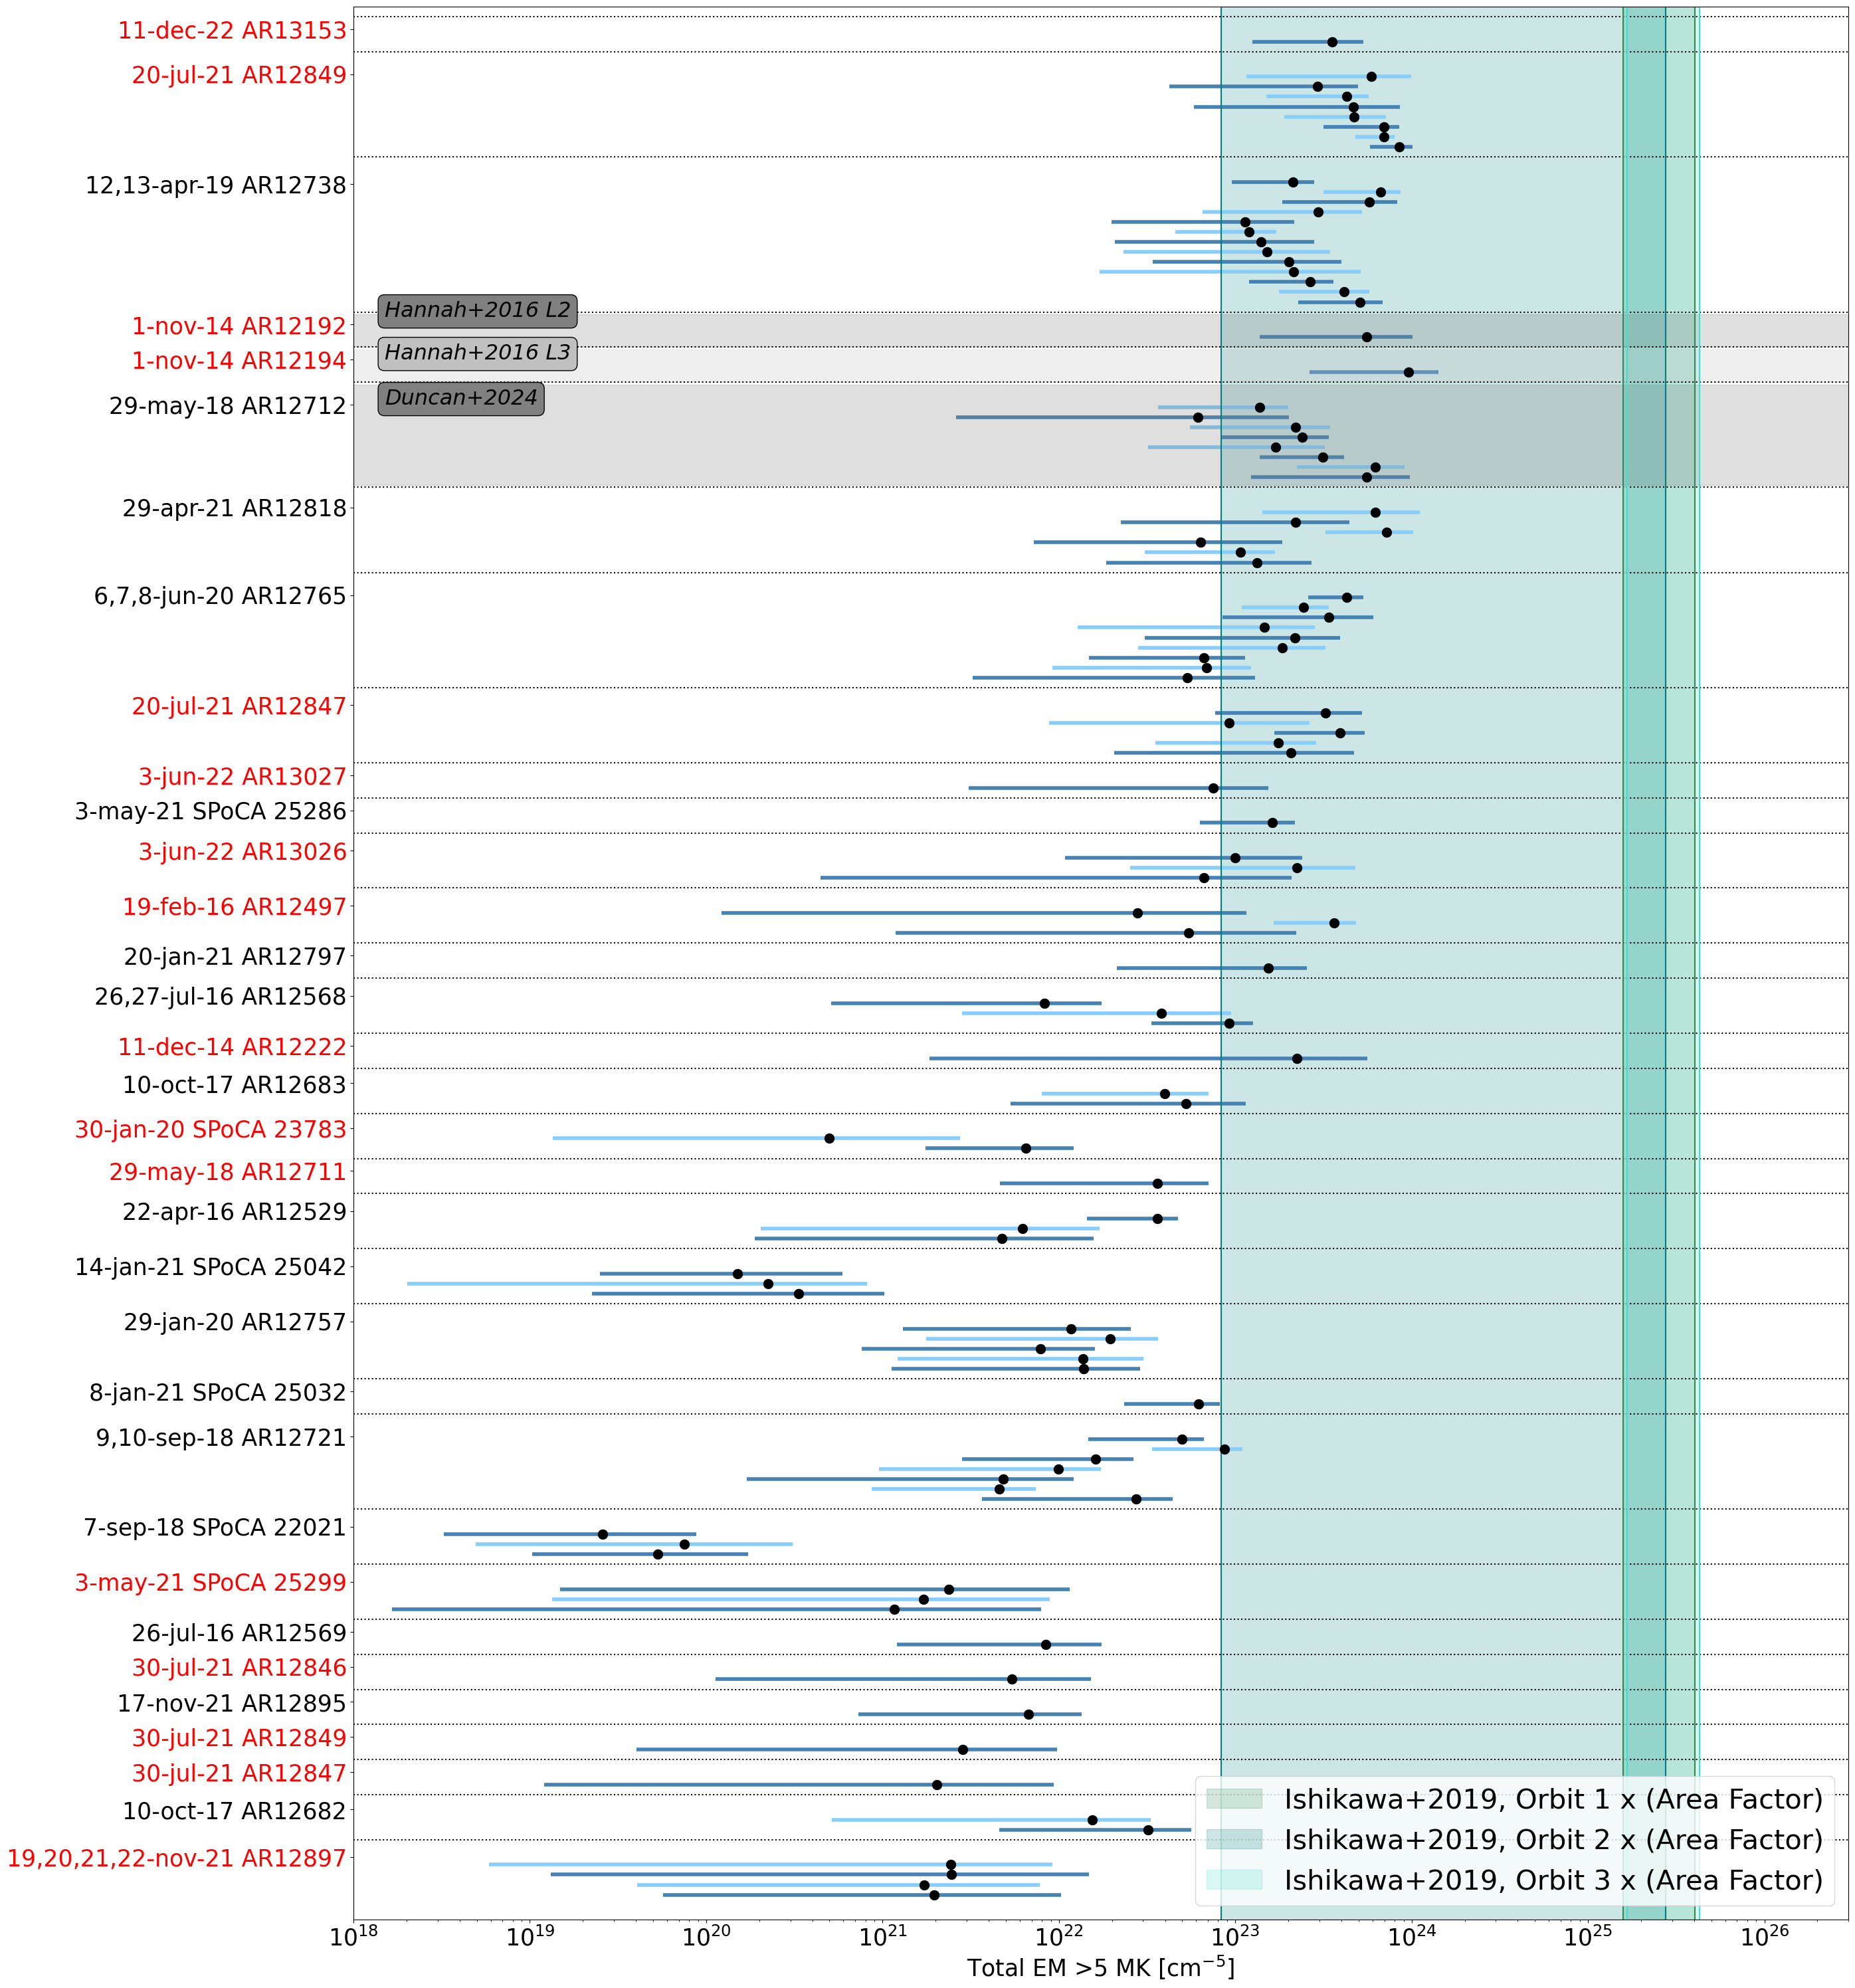

In [6]:
#Make EM > 5 MK needed arrays etc - in comparison with Ishikawa+Krucker2019

plot_all_intervals=False
plot_peak_ratio=False
plot_all_contig=True

labelfontsize=25

with open('/Users/jmdunca2/do-dem/reference_files/samesames.pickle', 'rb') as f:
    data = pickle.load(f)


samesames = data['same region lists']
grf = data['ghost ray flags']
#Lists per region
filelist = ana.get_same_region_file_lists(samesames, all_targets)

filelist = [filelist[i] for i in order]
samesames = [samesames[i] for i in order]
grf = [grf[i] for i in order]


#Factor to adjust integrated EM values
ishi_area = 360**2
ex_area = (360*u.arcsec)**2 #with units
nuarea = np.pi*150**2
factor = nuarea/ishi_area
print('Area Difference Factor: ', factor)

conversion = ((750*u.km)/(1*u.arcsec))**2
print(conversion)

#total area factor
taf = (ex_area*conversion).decompose()
print(taf)

orbits = [[6.3e45, 16e45]*(u.cm)**(-3), [0.033e45, 11e45]*(u.cm)**(-3), [6.6e45, 17e45]*(u.cm)**(-3), [6.3e45, 16e45]*(u.cm)**(-3)]
print('')

conv_orbits = []
for oo in orbits:
    conv_orbits.append([(oo[0]/taf).decompose().to(1/(u.cm**5)).value/factor, 
          (oo[1]/taf).decompose().to(1/(u.cm**5)).value/factor])

print(conv_orbits)





fig, ax = plt.subplots(1, 1, figsize=(28,30), tight_layout={'pad': 1})

ylabelvals = []
val=0
for i in range(0, len(filelist)):
    gf = filelist[i]

    regnum=0
    times=[]
    above5s=[]
    peakEMs=[]
    for f_ in gf:
        with open(f_, 'rb') as f:
            data = pickle.load(f)
        times.append(data['time_interval'])
        #above10s.append([factor*d for d in data['above_10MK']])
        above5s.append([d for d in data['above_5MK']])
        peakEMs.append(data['max'])

    contiguous, intervals, int_inds = ana.check_contig(times)
    if times:
        flipper=1
        if plot_all_intervals:
            colors=['hi', 'mediumpurple', 'rebeccapurple']
            for ii in int_inds:
                indx = np.arange(ii[0],ii[1])
                int_a5s = np.array(above5s)[indx]
                if plot_peak_ratio:
                    peaks=np.array(peakEMs)[indx]
                    int_a5s = [int_a10s[p]/peaks[p] for p in range(0, len(peaks))]
                for ia5 in int_a5s:
    
                    vert=val
                    xerrl = (np.array([ia5[0]- ia5[1]]))
                    #xerrl[np.where(xerrl < 1e10)] = 0.0
                    xerrh = (np.array([ia5[2] - ia5[0]]))
                    #xerrh[np.where(xerrh < 1e10)] = 0.0
                    
                    xerr = [xerrl, xerrh]                
                    ax.errorbar(ia5[0], vert, xerr=xerr, linestyle='', marker='o', linewidth=3, markersize=10, 
                                color=colors[flipper], zorder=1)
                    ax.errorbar(ia5[0], vert, linestyle='', marker='o', linewidth=3, markersize=10, color='black', zorder=2)
                    val+=1
                    regnum+=1
                flipper*=-1
                    
                val+=5
                
        elif plot_all_contig:
            colors=['hi', 'steelblue', 'lightskyblue']
            for ii in int_inds:
                indx = np.arange(ii[0],ii[1])
                int_a5s = np.array(above5s)[indx]
                if plot_peak_ratio:
                    peaks=np.array(peakEMs)[indx]
                    int_a5s = np.array([int_a5s[p]/peaks[p] for p in range(0, len(peaks))])
                    
                #Taking the mean and conducting error propogation
                la5s = np.log10(int_a5s[:,0])
                lmean = np.mean(la5s)
                ddif = la5s - np.log10(int_a5s[:,1])
                #ddif = la10s-ldowns
                edwn = 10**(lmean-np.sum([dd**2 for dd in ddif])**(1/2)/len(ddif))
                udif = np.log10(int_a5s[:,2])-la5s
                eup = 10**(np.sum([dd**2 for dd in udif])**(1/2)/len(udif) + lmean)
                input_val = 10**(lmean)

                vert=val
                xerrl = (np.array([input_val - edwn]))
                #xerrl[np.where(xerrl < 1e10)] = 0.0
                xerrh = (np.array([eup - input_val]))
                #xerrh[np.where(xerrh < 1e10)] = 0.0

                #xerr_og = [xerrl/factor, xerrh/factor]
                
                xerr = [xerrl, xerrh]
                ax.errorbar(input_val, vert, xerr=xerr, linestyle='', marker='o', linewidth=4, markersize=10, color=colors[flipper], zorder=1)
                #ax.errorbar(input_val/factor, vert, xerr=xerr_og, linestyle='', marker='o', linewidth=4, markersize=10, alpha=0.3, 
                #            color=colors[flipper], zorder=1)
                ax.errorbar(input_val, vert, linestyle='', marker='o', linewidth=4, markersize=10, color='black', zorder=2)
                #ax.errorbar(input_val/factor, vert, linestyle='', marker='o', linewidth=4, markersize=10, alpha=0.3, 
                #            color='black', zorder=2)
                val+=4
                regnum+=1
                flipper*=-1
                    
        
        ylabelvals.append(val-round(regnum/2.)+1.)
        ax.axhline(val+6, linestyle='dotted', color='black')#, label='New Regions', zorder=1)
        val+=10

startlevel=1.5e18
box_properties = dict(boxstyle='round', facecolor='green', alpha=0.5, edgecolor='black')
for i in range(0, len(plotlabs)):
    #print(plotlabs[i])
    if plotlabs[i] == '1-nov-14 AR12192':
        color='grey'
        box_properties = dict(boxstyle='round', facecolor=color, edgecolor='black')
        ax.text(startlevel, ylabelvals[i]+3, 'Hannah+2016 L2', fontsize=labelfontsize-2, style='italic', bbox=box_properties)
        ax.axhspan(ylabelvals[i]-9, ylabelvals[i]+4, color=color, alpha=0.25)
        
    if plotlabs[i] == '1-nov-14 AR12194':
        color='silver'
        box_properties = dict(boxstyle='round', facecolor=color, edgecolor='black')
        ax.text(startlevel, ylabelvals[i], 'Hannah+2016 L3', fontsize=labelfontsize-2, style='italic', bbox=box_properties)
        ax.axhspan(ylabelvals[i]-9, ylabelvals[i]+4, color=color, alpha=0.25)
        
    if plotlabs[i] == '29-may-18 AR12712':
        color='grey'
        box_properties = dict(boxstyle='round', facecolor=color, edgecolor='black')
        ax.text(startlevel, ylabelvals[i], 'Duncan+2024', fontsize=labelfontsize-2, style='italic', bbox=box_properties)
        ax.axhspan(ylabelvals[i]-32, ylabelvals[i]+8, color=color, alpha=0.25)
        


ax.set_yticks(ylabelvals)#[2:]
ax.set_yticklabels(labels=plotlabs, fontsize=labelfontsize)
ax.set_xscale('log')
plt.xticks(fontsize=labelfontsize)

colors=['seagreen', 'teal', 'turquoise', 'cyan']

if not plot_peak_ratio:
    ax.set_xlabel('Total EM >5 MK ['+(u.cm**(-5)).to_string('latex_inline')+']', fontsize=labelfontsize)
    countr=0
    for cc in conv_orbits[0:3]:
        ax.axvline(cc[0], color=colors[countr], zorder=2)
        ax.axvline(cc[1], color=colors[countr], zorder=2)
        ax.axvspan(cc[0], cc[1], alpha=0.2, color=colors[countr], 
                   label='Ishikawa+2019, Orbit '+str(countr+1)+' x (Area Factor)', zorder=0)
        countr+=1
     
ghost_ticks = np.where(grf)[0]
for i in ghost_ticks:
    ax.get_yticklabels()[i].set_color('red')
print('')

ax.set_ylim([-10,val])
ax.set_xlim([1e18,3e26])
ax.legend(loc='lower right', fontsize=labelfontsize+5)

if plot_all_intervals:
    if plot_peak_ratio:
        plt.savefig('all_values_above5_all_peak_rat_ishiadj.png', dpi=300)
    else:
        plt.savefig('all_values_above5_all_ishiadj.png', dpi=300)

if plot_all_contig:
    if plot_peak_ratio:
        plt.savefig('all_values_above5_contig_peak_rat_ishiadj.png', dpi=300)
    else:
        plt.savefig('all_values_above5_contig_ishiadj.png', dpi=300)



In [ ]:
2e27*

In [ ]:
order = np.argsort(np.array(region_above10s)[:,0])
regids = [samesames[i] for i in order]
grf = [grf[i] for i in order]

ghost_ticks = np.where(grf)[0]

plotlabs = ana.make_labels(regids)

#print('')
#print(len(labs))
#print(len(order))

region_time_hr = np.array((region_totaltime*u.s).to(u.hr))
#print(region_time_hr[order])


fig, ax = plt.subplots(1, 1, figsize=(28,10))


xerrl = (np.array(region_above10s)[:,0][order]/factor - np.array(region_above10s)[:,1][order]/factor)
xerrl[np.where(xerrl < 1e10)] = 0.0
xerrh = (np.array(region_above10s)[:,2][order]/factor - np.array(region_above10s)[:,0][order]/factor)
xerrh[np.where(xerrh < 1e10)] = 0.0

#xerr = [(np.array(region_above10s)[:,0][order] - np.array(region_above10s)[:,1][order]), 
#        (np.array(region_above10s)[:,2][order] - np.array(region_above10s)[:,0][order])]

xerr_nf = [xerrl, xerrh]

ax.errorbar(np.array(region_above10s)[:,0][order]/factor, np.arange(0, len(filelist), 1), 
            xerr=xerr_nf,
           linestyle='', marker='o', linewidth=3, markersize=10, color='indianred', 
            label='New Regions (no area factor)', alpha=0.3, zorder=0)

xerrl = (np.array(region_above10s)[:,0][order] - np.array(region_above10s)[:,1][order])
xerrl[np.where(xerrl < 1e10)] = 0.0
xerrh = (np.array(region_above10s)[:,2][order] - np.array(region_above10s)[:,0][order])
xerrh[np.where(xerrh < 1e10)] = 0.0

#xerr = [(np.array(region_above10s)[:,0][order] - np.array(region_above10s)[:,1][order]), 
#        (np.array(region_above10s)[:,2][order] - np.array(region_above10s)[:,0][order])]

xerr = [xerrl, xerrh]

ax.errorbar(np.array(region_above10s)[:,0][order], np.arange(0, len(filelist), 1), 
            xerr=xerr,
           linestyle='', marker='o', linewidth=3, markersize=10, color='indianred', label='New Regions', zorder=1)



oneerr = np.zeros((2,1))

ginds = [27, 28, 21]
colors = ['darkgreen', 'purple', 'royalblue']
labels = ['Duncan+2024', 'Hannah+2016 "L3"', 'Hannah+2016 "L2"']
gc=0
for gind in ginds:
    oneerr[0] = xerr[0][gind]
    oneerr[1] = xerr[1][gind]
    
    print(oneerr)
    
    ax.errorbar(np.array(region_above10s)[:,0][order][gind]/factor, np.arange(0, len(filelist), 1)[gind],
                xerr=oneerr/factor,
                linestyle='', marker='o', color=colors[gc], linewidth=3, markersize=10, alpha=0.3, zorder=2) #, s=140)
    
    
    ax.errorbar(np.array(region_above10s)[:,0][order][gind], np.arange(0, len(filelist), 1)[gind],
                xerr=oneerr,
                linestyle='', marker='o', color=colors[gc], linewidth=3, markersize=10, label=labels[gc], zorder=2) #, s=140)

    gc+=1



fntsz=25
ax.set_xscale('log')
ax.axvline(1.8e22, color='steelblue', zorder=0)
ax.axvline(1.5e23, color='steelblue', zorder=0)
ax.axvspan(1.8e22, 1.5e23, alpha=0.3, color='steelblue', label='Ishikawa+2017 95% Interval', zorder=0)
ax.set_yticks(np.arange(0, len(filelist))) #[2:]
ax.set_yticklabels(labels=plotlabs, fontsize=17) #[2:]
plt.xticks(fontsize=20)
ax.set_xlabel('Total EM >10 MK ('+(u.cm**(-5)).to_string('latex_inline')+')', fontsize=20)
ax.grid(axis = 'y', linestyle='dotted')
ax.legend(loc='lower right', fontsize=fntsz)
ax.set_ylim([-1,len(filelist)])
#ax.set_xlim([4e17,2e24])
ax.set_title('Time-weighted average and range of EM integrated >10 MK', fontsize=30, fontweight='bold')
for i in ghost_ticks:
    ax.get_yticklabels()[i].set_color('red')
print('')

plt.savefig('per_region_above10_new_postghost_postshut_ghostcorr.png', dpi=300)





def plot_range_v_dur(comp_cases, region_above10s, region_totalvals):

    ranges = np.array(region_above10s)[:,2] - np.array(region_above10s)[:,1]
    int_number = np.array(region_totalvals)
    normranges = ranges/np.array(region_above10s)[:,0]
    
    fig, ax = plt.subplots(1, 1, figsize=(5,5))
    ranges=ranges[comp_cases]
    normranges=normranges[comp_cases]
    int_number=int_number[comp_cases]
    plotlabs = ana.make_labels(samesames)
    sss=np.array(plotlabs)[comp_cases]
    
    TOT_DUR = [(time[1]-time[0]).to(u.min).value for time in times_per]*u.min
    
    TOT_DUR = TOT_DUR[comp_cases]
    
    ax.scatter(normranges, TOT_DUR)
    for i, label in enumerate(sss):
        plt.text(normranges[i] + 0.1, TOT_DUR[i] + 0.1*u.min, label, fontsize=12)
    #ax.set_yscale('log')
    #ax.set_xscale('log')   
    ax.set_title('Entire quiescent observation start-end duration vs. value-normalized range')

ctg_cases = np.where(contigs)[0]
print(ctg_cases)

int_number = np.array(region_totalvals)
comp_cases = np.where(int_number > 1)[0]
print(comp_cases)

both = np.where(np.logical_and(int_number > 1, contigs))[0]
plot_range_v_dur(both, region_above10s, region_totalvals)

nonconts = np.where(np.array(contigs) == False)[0]
print(nonconts)
plot_range_v_dur(nonconts, region_above10s, region_totalvals)


Below process: removing March 18 2023 region 1 from targets dictionary and saving it elsewhere, as ghost ray correction failed for that region and we are not incluidng it due to high level of potential contamination. 

In [13]:

# with open('/Users/jmdunca2/do-dem/reference_files/all_targets_postghost_postshut.pickle', 'rb') as f:
#     all_targets = pickle.load(f)


# all_targets['18-mar-23_1']

# march23file = '/Users/jmdunca2/do-dem/reference_files/save_18_mar_23_1.pickle'
# with open(march23file, 'wb') as f:
#         # Pickle the 'data' dictionary using the highest protocol available.
#         pickle.dump(all_targets['18-mar-23_1'], f, pickle.HIGHEST_PROTOCOL) 



In [15]:
# with open(march23file, 'rb') as f:
#     march23_target = pickle.load(f)

# march23_target

{'NOAA_ARID': ['AR13247', 'AR13250', 'AR13254'],
 'HARP': [],
 'datapaths': ['/Users/jmdunca2/nustar/mar-2023/20801021001/',
  '/Users/jmdunca2/nustar/mar-2023/20801022001/',
  '/Users/jmdunca2/nustar/mar-2023/20801023001/',
  '/Users/jmdunca2/nustar/mar-2023/20801024001/',
  '/Users/jmdunca2/nustar/mar-2023/20801026001/',
  '/Users/jmdunca2/nustar/mar-2023/20801027001/'],
 'obsids': ['20801021001',
  '20801022001',
  '20801023001',
  '20801024001',
  '20801026001',
  '20801027001'],
 'working_dir': '/Users/jmdunca2/do-dem/DEM_folders//initial_dem_18mar23_1/',
 'loc': ['limb'],
 'hale_class': [''],
 'method': 'fit',
 'notes': '',
 'goes_satellite': 16,
 'orbit durations': [<Quantity 59.38333333 min>,
  <Quantity 59.38333333 min>,
  <Quantity 59.38333333 min>,
  <Quantity 59.38333333 min>,
  <Quantity 41.62916667 min>,
  <Quantity 58.11666667 min>],
 'total duration': <Quantity 337.27916667 min>,
 'total livetime': <Quantity 1.37283489 min>,
 'gauss_stats': [([], 3), ([], 3), ([], 4), (

In [17]:

# with open('/Users/jmdunca2/do-dem/reference_files/all_targets_postghost_postshut.pickle', 'rb') as f:
#     all_targets = pickle.load(f)

# print(all_targets.keys())
    
# all_targets.pop('18-mar-23_1')

# print(all_targets.keys())

# with open('/Users/jmdunca2/do-dem/reference_files/all_targets_postghost_postshut.pickle', 'wb') as f:
#         # Pickle the 'data' dictionary using the highest protocol available.
#         pickle.dump(all_targets, f, pickle.HIGHEST_PROTOCOL) 


dict_keys(['01-nov-14_1', '01-nov-14_2', '11-dec-14', '19-feb-16', '22-apr-16_1', '22-apr-16_2', '26-jul-16_1', '27-jul-16_1', '26-jul-16_2', '10-oct-17', '29-may-18_1', '29-may-18_2', '07-sep-18', '09-sep-18', '10-sep-18', '12-apr-19', '13-apr-19', '29-jan-20', '06-jun-20', '07-jun-20', '08-jun-20', '09-jun-20', '08-jan-21', '14-jan-21', '20-jan-21', '29-apr-21', '03-may-21_1', '03-may-21_2', '30-jul-21_1', '30-jul-21_2', '17-nov-21_1', '19-nov-21', '20-nov-21', '22-nov-21_1', '22-nov-21_2', '03-jun-22_1', '03-jun-22_2', '06-sep-22', '09-dec-22', '17-nov-21_2', '21-nov-21', '30-jan-20', '20-jul-21', '24-feb-22', '25-feb-22', '27-feb-22', '18-mar-23_1', '18-mar-23_2', '11-dec-22_2'])
dict_keys(['01-nov-14_1', '01-nov-14_2', '11-dec-14', '19-feb-16', '22-apr-16_1', '22-apr-16_2', '26-jul-16_1', '27-jul-16_1', '26-jul-16_2', '10-oct-17', '29-may-18_1', '29-may-18_2', '07-sep-18', '09-sep-18', '10-sep-18', '12-apr-19', '13-apr-19', '29-jan-20', '06-jun-20', '07-jun-20', '08-jun-20', '09-j

In [18]:

# with open('/Users/jmdunca2/do-dem/reference_files/all_targets_postghost_postshut.pickle', 'rb') as f:
#     all_targets = pickle.load(f)

# print(all_targets.keys())

dict_keys(['01-nov-14_1', '01-nov-14_2', '11-dec-14', '19-feb-16', '22-apr-16_1', '22-apr-16_2', '26-jul-16_1', '27-jul-16_1', '26-jul-16_2', '10-oct-17', '29-may-18_1', '29-may-18_2', '07-sep-18', '09-sep-18', '10-sep-18', '12-apr-19', '13-apr-19', '29-jan-20', '06-jun-20', '07-jun-20', '08-jun-20', '09-jun-20', '08-jan-21', '14-jan-21', '20-jan-21', '29-apr-21', '03-may-21_1', '03-may-21_2', '30-jul-21_1', '30-jul-21_2', '17-nov-21_1', '19-nov-21', '20-nov-21', '22-nov-21_1', '22-nov-21_2', '03-jun-22_1', '03-jun-22_2', '06-sep-22', '09-dec-22', '17-nov-21_2', '21-nov-21', '30-jan-20', '20-jul-21', '24-feb-22', '25-feb-22', '27-feb-22', '18-mar-23_2', '11-dec-22_2'])
